# Stock News Sentiment → Next Day Return Prediction

End-to-end pipeline:
1. **Ingest** — pull headlines from GDELT BigQuery
2. **Score** — run FinBERT, VADER, V2Tone, and LLMs (via Ollama)
3. **Engineer** — compute daily sentiment features (shock, momentum, volume, etc.)
4. **Merge** — join with yfinance price data + VIX
5. **Train** — XGBoost grid search with chronological train/val/test split, val for param grid fitting, walkthrough for pre-test evaluation
6. **Evaluate** — validation & holdout diagnostics, trading simulation
7. **Backup / Restore** — snapshot all artefacts to disk

---
## 0 · Configuration

All user-tunable settings live here. No need to edit any other cell.

In [118]:
# ── Target stock ──────────────────────────────────────────────────────────────
TICKER       = "NVDA"
COMPANY_NAME = "NVIDIA"
KEYWORDS     = ["NVIDIA", "NVDA"]   # used for GDELT regex and headline filtering

# ── Date range ────────────────────────────────────────────────────────────────
DATE_FROM = "2025-04-15"
DATE_TO   = "2026-04-15"

# ── Sentiment model toggles ───────────────────────────────────────────────────
RUN_FINBERT = True
RUN_VADER   = True
RUN_V2TONE  = True
RUN_OLLAMA   = True

# ── Ollama / LLM ─────────────────────────────────────────────────────────────
OLLAMA_BASE_URL = "http://127.0.0.1:11434"

# Add, remove, or swap any Ollama-compatible model.
# Format: (name, ollama_model_id)
# "name" becomes the score column prefix, e.g. "gemma3" -> "gemma3_score"
LLM_MODELS = [
    ("gemma3_4", "gemma3:4b"),
    ("gemma3_12", "gemma3:12b"),
    # ("llama3",  "llama3.1:8b"),
    # ("mistral", "mistral:7b"),
    # ("phi3",    "phi3:mini"),
    # ("qwen",    "qwen2.5:7b"),
]



# ── BigQuery ──────────────────────────────────────────────────────────────────
import os
from dotenv import load_dotenv
load_dotenv(os.path.join(os.getcwd(), ".env"))
GCP_CREDENTIALS_PATH = os.getenv("GCP_CREDENTIALS_PATH")
GCP_PROJECT_ID       = os.getenv("GCP_PROJECT_ID")


# ── Fetch / checkpoint settings ───────────────────────────────────────────────
FETCH_DELAY_SECONDS = 0.0    # polite pause between BigQuery calls
LLM_MAX_RETRIES   = 3
LLM_RETRY_DELAY   = 2      # seconds between retries
LLM_POLL_INTERVAL = 15     # seconds between model-detection polls
LLM_CHUNK_SIZE    = 500     # number of articles sent per LLM API call
LLM_WORKERS       = 8      # parallel LLM calls (set to CPU cores or less)

# ── Price / feature engineering ───────────────────────────────────────────────
TARGET_HORIZON_DAYS = 1      # n-day forward return for binary target
LOOKBACK_DAYS       = 80     # warm-up days downloaded before DATE_FROM (needs ~55 trading days for ma_50)
ROLLING_WINDOW      = 30     # long-term sentiment baseline window
NEUTRAL_MULTIPLIER  = 0.02   # near-neutral article filter (× rolling std)

# ── Train / val / test split ──────────────────────────────────────────────────
VALIDATION_SPLIT = 0.20      # fraction of pre-test data held for validation

WF_TRAIN_WINDOW = 150
WF_STEP         = 20

# ── XGBoost grid search ───────────────────────────────────────────────────────
XGB_FEATURES = [
    "avg_score", "momentum", "momentum_10", "std", "shock",
    "accel", "spx_return", "spx_momentum_5", "price_momentum_5d",
    "volatility_20d",
]

TARGET_COL          = "target"
DECISION_THRESHOLD  = 0.5    # set to "X" to enable auto-threshold search
THRESHOLD_DEAD_ZONE = (0.0, 0.0)  # predictions in (low, high) are abstained
SELECTION_METRIC    = "roc_auc"  # accuracy | precision | recall | f1 | roc_auc
SCALE_POS_WEIGHT    = True  # True → compensate for class imbalance

XGB_PARAM_GRID = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [2, 3],
    "min_child_weight":  [5, 10, 20],
    "learning_rate":     [0.01, 0.05],
    "subsample":         [0.5, 0.6],
    "colsample_bytree":  [0.4, 0.6],
    "gamma":             [1.0, 3.0],
    "reg_alpha":         [1.0, 5.0],
    "reg_lambda":        [5.0, 15.0],
}

# ── Trading simulation ────────────────────────────────────────────────────────
SIM_MODEL = "tone"
LONG_THRESHOLD  = 0.500001
SHORT_THRESHOLD = 0.499999

# ── Paths ─────────────────────────────────────────────────────────────────────
SESSION_LOG_DIR = r"D:\PRODStockNews\session_logs"   # checkpoints, parquets, frozen models
BACKUP_ROOT     = r"D:\PRODStockNews\backup"

# ── Derived (do not edit) ─────────────────────────────────────────────────────
from datetime import datetime, timedelta
import re

SQL_PATTERN = f"(?i){'|'.join(KEYWORDS)}"
_start = datetime.strptime(DATE_FROM, "%Y-%m-%d")
_end   = datetime.strptime(DATE_TO,   "%Y-%m-%d")
TEST_CUTOFF_DATE = (
    _start + timedelta(seconds=(_end - _start).total_seconds() * 0.8)
).strftime("%Y-%m-%d")
KEYWORDS_RE = re.compile(f"({'|'.join(KEYWORDS)})", re.IGNORECASE)

print(f"Ticker            : {TICKER}")
print(f"Date range        : {DATE_FROM} → {DATE_TO}")
print(f"Train/test cutoff : {TEST_CUTOFF_DATE}")
print(f"SQL regex pattern : {SQL_PATTERN}")
print(f"Session log dir   : {SESSION_LOG_DIR}")

Ticker            : NVDA
Date range        : 2025-04-15 → 2026-04-15
Train/test cutoff : 2026-02-01
SQL regex pattern : (?i)NVIDIA|NVDA
Session log dir   : D:\PRODStockNews\session_logs


---
## 1 · Imports

In [2]:
import html
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import requests
import seaborn as sns
import torch
import yfinance as yf
from google.cloud import bigquery
from sklearn.metrics import (
    accuracy_score, auc, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_curve,
)
from sklearn.model_selection import ParameterGrid
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from xgboost import XGBClassifier

tqdm.pandas()
print("Imports OK")

c:\Users\JG\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


---
## 2 · GDELT Ingest

Fetches headline data from `gdelt-bq.gdeltv2.gkg_partitioned` with per-day
checkpointing so long runs are resumable after a crash.

In [7]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = GCP_CREDENTIALS_PATH
bq_client = bigquery.Client(project=GCP_PROJECT_ID)
os.makedirs(SESSION_LOG_DIR, exist_ok=True)


def _fetch_day(target_date: date, sql_pattern: str) -> pd.DataFrame:
    """Run a single-day BigQuery partition scan and return a DataFrame."""
    date_str = target_date.strftime("%Y-%m-%d")
    query = f"""
        SELECT
            _PARTITIONDATE AS date,
            REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>') AS headline,
            CAST(SPLIT(V2Tone, ',')[OFFSET(0)] AS FLOAT64) AS V2Tone,
            DocumentIdentifier AS url
        FROM `gdelt-bq.gdeltv2.gkg_partitioned`
        WHERE
            _PARTITIONDATE = '{date_str}'
            AND REGEXP_CONTAINS(
                REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>'),
                r'{sql_pattern}'
            )
            AND REGEXP_EXTRACT(Extras, r'<PAGE_TITLE>(.*?)</PAGE_TITLE>') IS NOT NULL
    """
    return bq_client.query(query).to_dataframe()


def fetch_articles(
    date_from: str,
    date_to: str,
    sql_pattern: str,
    ticker: str = TICKER,
    delay: float = FETCH_DELAY_SECONDS,
    checkpoint_dir: str | None = None,
    resume_from: str | None = None,
) -> pd.DataFrame:
    """
    Fetch GDELT articles across a date range.

    Args:
        date_from, date_to : ISO date strings (inclusive).
        sql_pattern        : BigQuery REGEXP_CONTAINS pattern.
        ticker             : Used to name checkpoint files.
        delay              : Seconds to sleep between requests.
        checkpoint_dir     : If set, save one parquet per day for crash recovery.
                             Defaults to SESSION_LOG_DIR/checkpoints_{ticker}.
        resume_from        : Skip days before this ISO date.

    Returns:
        Combined DataFrame with columns [date, headline, V2Tone, url].
    """
    if checkpoint_dir is None:
        checkpoint_dir = os.path.join(SESSION_LOG_DIR, f"checkpoints_{ticker}")
    os.makedirs(checkpoint_dir, exist_ok=True)

    start = date.fromisoformat(date_from)
    end   = date.fromisoformat(date_to)
    total_days   = (end - start).days + 1
    resume_date  = date.fromisoformat(resume_from) if resume_from else start

    all_frames, failed_dates = [], []
    current = start

    print(f"Ticker     : {ticker}")
    print(f"Date range : {date_from} → {date_to} ({total_days} days)")
    if resume_from:
        print(f"Resuming from {resume_from}")

    while current <= end:
        day_num   = (current - start).days + 1
        date_str  = current.strftime("%Y-%m-%d")
        ckpt_path = os.path.join(checkpoint_dir, f"{ticker}_{date_str}.parquet")

        if os.path.exists(ckpt_path):
            df = pd.read_parquet(ckpt_path)
            all_frames.append(df)
            print(f"  [{day_num:>4}/{total_days}] {date_str}  (cached) → {len(df)} rows")
            current += timedelta(days=1)
            continue

        if current < resume_date:
            print(f"  [{day_num:>4}/{total_days}] {date_str}  (skipped)")
            current += timedelta(days=1)
            continue

        print(f"  [{day_num:>4}/{total_days}] {date_str}", end="", flush=True)
        try:
            df = _fetch_day(current, sql_pattern)
            df = df.drop_duplicates(subset=["headline", "date"])
            df.to_parquet(ckpt_path, index=False)
            all_frames.append(df)
            print(f"  → {len(df):>4} rows")
        except Exception as exc:
            failed_dates.append(date_str)
            print(f"  → FAILED: {exc}")

        current += timedelta(days=1)
        if current <= end:
            time.sleep(delay)

    if not all_frames:
        print("\nNo articles found in range.")
        return pd.DataFrame(columns=["date", "headline", "V2Tone", "url"])

    combined = (
        pd.concat(all_frames, ignore_index=True)
        .drop_duplicates(subset=["headline", "date"])
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"\n{'─'*50}")
    print(f"Total rows   : {len(combined)}")
    print(f"Days fetched : {total_days - len(failed_dates)}/{total_days}")
    if failed_dates:
        print(f"Failed dates : {', '.join(failed_dates)}")
        print("  → Re-run with resume_from='<first failed date>' to retry")
    return combined


# ── Run ───────────────────────────────────────────────────────────────────────
df = fetch_articles(
    DATE_FROM, DATE_TO, SQL_PATTERN,
    # resume_from="2024-06-15",  # uncomment to resume after a crash
)

Ticker     : NVDA
Date range : 2025-04-15 → 2026-04-15 (366 days)
  [   1/366] 2025-04-15  (cached) → 389 rows
  [   2/366] 2025-04-16  (cached) → 911 rows
  [   3/366] 2025-04-17  (cached) → 407 rows
  [   4/366] 2025-04-18  (cached) → 185 rows
  [   5/366] 2025-04-19  (cached) → 65 rows
  [   6/366] 2025-04-20  (cached) → 70 rows
  [   7/366] 2025-04-21  (cached) → 165 rows
  [   8/366] 2025-04-22  (cached) → 171 rows
  [   9/366] 2025-04-23  (cached) → 123 rows
  [  10/366] 2025-04-24  (cached) → 126 rows
  [  11/366] 2025-04-25  (cached) → 121 rows
  [  12/366] 2025-04-26  (cached) → 61 rows
  [  13/366] 2025-04-27  (cached) → 66 rows
  [  14/366] 2025-04-28  (cached) → 205 rows
  [  15/366] 2025-04-29  (cached) → 134 rows
  [  16/366] 2025-04-30  (cached) → 169 rows
  [  17/366] 2025-05-01  (cached) → 165 rows
  [  18/366] 2025-05-02  (cached) → 157 rows
  [  19/366] 2025-05-03  (cached) → 59 rows
  [  20/366] 2025-05-04  (cached) → 50 rows
  [  21/366] 2025-05-05  (cached) → 109 

---
## 3 · Headline Cleaning

In [8]:
def clean_headline(text: str | None) -> str | None:
    """
    Clean and validate a single headline string.

    Returns the cleaned text, or None if the headline should be discarded
    (missing keyword, non-ASCII characters, or empty after cleaning).
    """
    if not text or pd.isna(text):
        return None

    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", "", text)   # strip residual HTML tags
    text = " ".join(text.split())          # normalise whitespace

    if not KEYWORDS_RE.search(text):
        return None

    if not all(ord(c) < 128 for c in text):
        return None

    return text.strip() or None


def clean_dataframe(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Apply cleaning, deduplication, and return the filtered DataFrame."""
    df_clean = df_raw.copy()
    df_clean["headline"] = df_clean["headline"].apply(clean_headline)
    df_clean = df_clean.dropna(subset=["headline"])

    # Deduplicate on a 30-char headline prefix (catches near-identical titles)
    df_clean["_prefix"] = df_clean["headline"].str[:30]
    df_clean = df_clean.drop_duplicates(subset="_prefix").drop(columns="_prefix")

    return df_clean.reset_index(drop=True)


df = clean_dataframe(df)

articles_per_day = (
    df.dropna(subset=["date"])
    .assign(date=pd.to_datetime(df["date"]).dt.normalize())
    .groupby("date", as_index=False)
    .size()
    .rename(columns={"size": "article_count"})
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Headlines after cleaning : {len(df):,}")
print(f"Days with coverage       : {len(articles_per_day)}")
display(articles_per_day.head())

Headlines after cleaning : 34,890
Days with coverage       : 349


,date,article_count
0,2025-04-15,200
1,2025-04-16,464
2,2025-04-17,187
3,2025-04-18,100
4,2025-04-19,32


---
## 4 · Sentiment Scoring

Four scorers run in sequence:
- **Gemma 3 4B & 12B by default** (via Ollama, chunked + checkpointed)
- **FinBERT** (HuggingFace)
- **VADER**
- **V2Tone** (GDELT built-in)

In [9]:
# ── Ollama helpers ────────────────────────────────────────────────────────────

def _ollama_is_running(base_url: str = OLLAMA_BASE_URL) -> bool:
    """Return True if Ollama is reachable."""
    try:
        r = requests.get(f"{base_url}/api/tags", timeout=5)
        return r.ok
    except Exception:
        return False


def ensure_model(model_id: str, poll_interval: int = LLM_POLL_INTERVAL) -> None:
    """Block until Ollama is up and model_id is available locally; pulls if needed."""
    print(f"\n{'='*55}")
    print(f"  Model      : {model_id}")
    print(f"  Ollama URL : {OLLAMA_BASE_URL}")
    print(f"{'='*55}")
    while not _ollama_is_running():
        print(f"  Ollama not reachable - retrying in {poll_interval}s ...")
        time.sleep(poll_interval)
    try:
        r = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
        pulled = [m["name"] for m in r.json().get("models", [])]
        if not any(model_id.lower() in p.lower() for p in pulled):
            print(f"  Pulling '{model_id}' (this may take a while) ...")
            requests.post(f"{OLLAMA_BASE_URL}/api/pull", json={"name": model_id}, timeout=600)
            print("  Pull complete.")
    except Exception as e:
        print(f"  Warning: could not verify model list - {e}")
    print(f"  Ready: '{model_id}'\n")


def _build_llm_prompt(headline: str) -> str:
    text = "" if pd.isna(headline) else str(headline).strip()
    return (
        f'/no_think Does this statement reflect positively, negatively, or neutrally '
        f'on the stock price of {COMPANY_NAME}?\n\n"{text}"\n\n'
        "Return only one number between -1 and 1."
    )


def _parse_llm_response(text: str) -> float:
    value = re.sub(r"<think>.*?</think>", "", text or "", flags=re.IGNORECASE | re.DOTALL).strip()
    match = re.search(r"-?\d*\.?\d+", value)
    if not match:
        return 0.0
    score = float(match.group())
    return score if -1 <= score <= 1 else 0.0


def _score_one(headline: str, model_id: str, timeout: int = 60) -> float:
    """Score a single headline via Ollama with retries."""
    for attempt in range(LLM_MAX_RETRIES):
        try:
            r = requests.post(
                f"{OLLAMA_BASE_URL}/api/chat",
                json={
                    "model": model_id,
                    "messages": [{"role": "user", "content": _build_llm_prompt(headline)}],
                    "stream": False,
                    "options": {
                        "temperature": 0.2,
                        "top_p":       0.95,
                        "num_predict": 16,
                        "stop":        ["\n"],
                    },
                },
                timeout=timeout,
            )            
            r.raise_for_status()
            msg = r.json()["message"]
         #   print(repr(msg))   # <-- temp debug
            return _parse_llm_response(msg["content"])
        except Exception as e:
            print(f"ERROR: {e}")
            if attempt < LLM_MAX_RETRIES - 1:
                time.sleep(LLM_RETRY_DELAY)
    return 0.0


def run_llm_chunked(
    df_input: pd.DataFrame,
    model_id: str,
    out_col: str,
    chunk_size: int = LLM_CHUNK_SIZE,
    workers: int = LLM_WORKERS,
    checkpoint_path: str | None = None,
) -> pd.DataFrame:
    """Score headlines in parallel chunks with parquet checkpointing."""
    if checkpoint_path is None:
        os.makedirs(SESSION_LOG_DIR, exist_ok=True)
        checkpoint_path = os.path.join(SESSION_LOG_DIR, "checkpoint.parquet")

    if os.path.exists(checkpoint_path):
        ckpt = pd.read_parquet(checkpoint_path)
        if out_col in ckpt.columns:
            shared_idx = df_input.index.intersection(ckpt.index)
            done_idx   = shared_idx[ckpt.loc[shared_idx, out_col].notna()]
            done       = df_input.loc[done_idx].copy()
            done[out_col] = ckpt.loc[done_idx, out_col].values
            remaining  = df_input[~df_input.index.isin(done_idx)]
            results    = [done]
            print(f"  [checkpoint] Resuming '{out_col}' - {len(done):,} scored, {len(remaining):,} remaining.")
        else:
            remaining = df_input.copy()
            results   = []
            print(f"  [checkpoint] Checkpoint exists, no '{out_col}' yet - scoring all rows.")
    else:
        ckpt      = None
        remaining = df_input.copy()
        results   = []
        print(f"  [checkpoint] No checkpoint - starting fresh for '{out_col}'.")

    if remaining.empty:
        print("All rows already scored.")
        return pd.concat(results).sort_index() if results else df_input.copy().assign(**{out_col: []})

    chunks = [remaining.iloc[i:i + chunk_size] for i in range(0, len(remaining), chunk_size)]
    print(f"Scoring {len(remaining):,} rows in {len(chunks)} chunks of {chunk_size} using '{model_id}'")

    for idx, chunk in enumerate(chunks):
        headlines = chunk["headline"].tolist()
        scores = [None] * len(headlines)
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {executor.submit(_score_one, h, model_id): i for i, h in enumerate(headlines)}
            with tqdm(total=len(headlines), desc=f"Chunk {idx + 1}/{len(chunks)}") as pbar:
                for future in as_completed(futures):
                    scores[futures[future]] = future.result()
                    pbar.update(1)
        chunk = chunk.copy()
        chunk[out_col] = scores
        results.append(chunk)
        current = pd.concat(results).sort_index()
        if ckpt is not None:
            # Add rows that are new (not yet in ckpt), then update the column
            new_rows = current.index.difference(ckpt.index)
            if len(new_rows):
                ckpt = pd.concat([ckpt, current.loc[new_rows]]).sort_index()
            ckpt.loc[current.index, out_col] = current[out_col].values
            ckpt.to_parquet(checkpoint_path)
        else:
            current.to_parquet(checkpoint_path)
            ckpt = pd.read_parquet(checkpoint_path)
        print(f"  Chunk {idx + 1}/{len(chunks)} saved - {sum(len(r) for r in results):,} total")

    final = pd.concat(results).sort_index()
    return final


# ── FinBERT helpers ───────────────────────────────────────────────────────────

if RUN_FINBERT:
    print("Loading FinBERT...")
    _finbert_tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    _finbert_model     = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
    print("FinBERT ready.")


def score_finbert(text: str) -> str:
    """Return 'positive', 'neutral', or 'negative'."""
    text = "" if pd.isna(text) else str(text)
    inputs = _finbert_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = _finbert_model(**inputs)
    idx = torch.argmax(outputs.logits, dim=1).item()
    return ["negative", "neutral", "positive"][idx]


_FINBERT_MAP = {"negative": -1, "neutral": 0, "positive": 1}


# ── VADER helper ──────────────────────────────────────────────────────────────

if RUN_VADER:
    _vader = SentimentIntensityAnalyzer()


def score_vader(text: str) -> float:
    """Return VADER compound score in [-1, 1]."""
    return _vader.polarity_scores("" if pd.isna(text) else str(text))["compound"]


# ── V2Tone helper ─────────────────────────────────────────────────────────────

def parse_v2tone(tone_str) -> float | None:
    """Extract the first tone value and normalise to [-1, 1]."""
    try:
        return float(str(tone_str).split(",")[0]) / 10
    except Exception:
        return None


Loading FinBERT...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22335.54it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT ready.


In [10]:
# ── Run all scorers ───────────────────────────────────────────────────────────

working = df[["date", "headline", "V2Tone"]].copy().dropna(subset=["headline"])

# LLM models via Ollama — any model listed in LLM_MODELS
if RUN_OLLAMA:
    for name, model_id in LLM_MODELS:
        out_col = f"{name}_score"
        ensure_model(model_id)
        working = run_llm_chunked(working, model_id=model_id, out_col=out_col)
        print(f"{name} complete - '{out_col}' added.")

# FinBERT
if RUN_FINBERT:
    print("Running FinBERT...")
    working["finbert_label"] = working["headline"].progress_apply(score_finbert)
    working["finbert_score"] = working["finbert_label"].map(_FINBERT_MAP)
    print("FinBERT done.")
else:
    working["finbert_score"] = 0.0

# VADER
if RUN_VADER:
    print("Running VADER...")
    working["vader_score"] = working["headline"].progress_apply(score_vader)
    print("VADER done.")
else:
    working["vader_score"] = 0.0

# V2Tone
if RUN_V2TONE:
    print("Running V2Tone...")
    working["v2tone_score"] = working["V2Tone"].progress_apply(parse_v2tone)
    print("V2Tone done.")
else:
    working["v2tone_score"] = 0.0

# Assemble final sentiment DataFrame
_LLM_cols = [f"{name}_score" for name, _ in LLM_MODELS if f"{name}_score" in working.columns]
if "LLM_score" in working.columns and "LLM_score" not in _LLM_cols:
    _LLM_cols = ["LLM_score"] + _LLM_cols
df_sentiments = working[
    ["date", "headline", "v2tone_score", "vader_score", "finbert_score"] + _LLM_cols
].reset_index(drop=True)
    
output_filename = "df_sentiments_final.parquet"
full_output_path = os.path.join(SESSION_LOG_DIR, output_filename)

# 2. Save using the full path
df_sentiments.to_parquet(full_output_path, index=False)

print(f"\n{'='*55}")
print(f"Pipeline complete — {len(df_sentiments):,} rows")
print(f"Columns : {df_sentiments.columns.tolist()}")
print(f"Saved to: {os.path.abspath(full_output_path)}")
print(f"{'='*55}")



  Model      : gemma3:4b
  Ollama URL : http://127.0.0.1:11434
  Ready: 'gemma3:4b'

  [checkpoint] No checkpoint - starting fresh for 'gemma3_4_score'.
Scoring 34,890 rows in 70 chunks of 500 using 'gemma3:4b'


Chunk 1/70: 100%|██████████| 500/500 [01:08<00:00,  7.25it/s]


  Chunk 1/70 saved - 500 total


Chunk 2/70: 100%|██████████| 500/500 [01:03<00:00,  7.84it/s]


  Chunk 2/70 saved - 1,000 total


...

FinBERT done.
Running VADER...


100%|██████████| 34890/34890 [00:01<00:00, 20536.77it/s]


VADER done.
Running V2Tone...


100%|██████████| 34890/34890 [00:00<00:00, 396533.95it/s]


V2Tone done.

Pipeline complete — 34,890 rows
Columns : ['date', 'headline', 'v2tone_score', 'vader_score', 'finbert_score', 'gemma3_4_score', 'gemma3_12_score']
Saved to: D:\PRODStockNews\session_logs\df_sentiments_final.parquet


---
## 5 · Feature Engineering

For each sentiment model, compute daily aggregates and derived features:
shock, momentum, volume, surprise, acceleration, extreme flag, sign flip,
and a cross-model disagreement signal.

In [91]:
# ── Optional: reload from disk ────────────────────────────────────────────────
# df_sentiments = pd.read_parquet("df_sentiments_final.parquet")
# df_sentiments["date"] = pd.to_datetime(df_sentiments["date"], errors="coerce")

def build_daily_features(df: pd.DataFrame, models: list[str], rolling_window: int = ROLLING_WINDOW) -> pd.DataFrame:
    """
    Aggregate article-level sentiment to daily features for each model.

    Features per model:
        {m}_avg, {m}_std, {m}_count,
        {m}_long_term, {m}_shock,
        {m}_volume,
        {m}_5d_avg,  {m}_momentum,
        {m}_10d_avg, {m}_momentum_10,
        {m}_accel, {m}_extreme, {m}_flip

    Plus cross-model: model_disagreement.
    """
    score_cols = {m: f"{m}_score" for m in models if f"{m}_score" in df.columns}

    agg_kwargs = {}
    for prefix, col in score_cols.items():
        agg_kwargs[f"{prefix}_avg"]   = (col, "mean")
        agg_kwargs[f"{prefix}_std"]   = (col, "std")
        agg_kwargs[f"{prefix}_count"] = (col, "count")

    out = df.groupby("date", as_index=False).agg(**agg_kwargs)

    std_cols = [f"{m}_std" for m in score_cols]
    out[std_cols] = out[std_cols].fillna(0.0)

    for m in score_cols:
        avg = f"{m}_avg"
        std = f"{m}_std"

        out[f"{m}_long_term"]   = out[avg].rolling(rolling_window, min_periods=1).mean()
        out[f"{m}_shock"]       = np.where(out[std] != 0, (out[avg] - out[f"{m}_long_term"]) / out[std], 0.0)
        out[f"{m}_volume"]      = out[avg] * np.sqrt(out[f"{m}_count"])
        out[f"{m}_5d_avg"]      = out[avg].rolling(5, min_periods=1).mean()
        out[f"{m}_momentum"]    = out[avg] - out[f"{m}_5d_avg"]
        out[f"{m}_10d_avg"]     = out[avg].rolling(10, min_periods=1).mean()
        out[f"{m}_momentum_10"] = out[avg] - out[f"{m}_10d_avg"]
        out[f"{m}_accel"]       = out[avg].diff().diff()
        out[f"{m}_extreme"]     = (out[avg].abs() > 0.5).astype(int)
        out[f"{m}_flip"]        = ((out[avg] > 0) != (out[avg].shift(1) > 0)).astype(int)
        

    out["model_disagreement"] = out[[f"{m}_avg" for m in score_cols]].std(axis=1)

    # Fill NaN from diff/rolling at series start
    fill_cols = [f"{m}{s}" for m in score_cols for s in ("_accel", "_momentum", "_momentum_10", "_shock")]
    out[fill_cols] = out[fill_cols].fillna(0.0)

    return out


SENTIMENT_MODELS = []
if RUN_FINBERT:
    SENTIMENT_MODELS.append("bert")
if RUN_VADER:
    SENTIMENT_MODELS.append("vader")
if RUN_V2TONE:
    SENTIMENT_MODELS.append("tone")
if RUN_OLLAMA:
    SENTIMENT_MODELS.extend([name for name, _ in LLM_MODELS])

# Rename finbert/v2tone columns to match model prefixes expected downstream
_renames = {"finbert_score": "bert_score", "v2tone_score": "tone_score"}
df_sentiments = df_sentiments.rename(columns={k: v for k, v in _renames.items() if k in df_sentiments.columns})
df_sentiments["date"] = pd.to_datetime(df_sentiments["date"])

df_avg_sentiment = build_daily_features(df_sentiments, models=SENTIMENT_MODELS)

print(f"Daily feature rows : {len(df_avg_sentiment)}")
print(f"Total columns      : {len(df_avg_sentiment.columns)}")
display(df_avg_sentiment.head())

Daily feature rows : 349
Total columns      : 67


,date,bert_avg,bert_std,bert_count,vader_avg,vader_std,vader_count,tone_avg,tone_std,tone_count,...,gemma3_12_shock,gemma3_12_volume,gemma3_12_5d_avg,gemma3_12_momentum,gemma3_12_10d_avg,gemma3_12_momentum_10,gemma3_12_accel,gemma3_12_extreme,gemma3_12_flip,model_disagreement
0,2025-04-15,0.485000,0.814304,200,0.035940,0.232178,200,0.084749,0.242778,200,...,0.000000,4.546697,0.321500,0.000000,0.321500,0.000000,0.000000,0,1,0.245120
1,2025-04-16,0.336207,0.643210,464,-0.054424,0.269686,464,-0.184666,0.316137,464,...,-0.734921,-8.788032,-0.043237,-0.364737,-0.043237,-0.364737,0.000000,0,1,0.315510
2,2025-04-17,0.481283,0.720978,187,-0.026482,0.329979,187,-0.101297,0.331199,187,...,-0.251831,-3.034781,-0.102800,-0.119125,-0.102800,-0.119125,0.915523,0,0,0.279977
3,2025-04-18,0.400000,0.828775,100,0.097708,0.291742,100,0.015558,0.248225,100,...,0.177387,0.015000,-0.076725,0.078225,-0.076725,0.078225,0.037376,0,1,0.161105
4,2025-04-19,0.531250,0.671271,32,0.057737,0.265211,32,-0.054217,0.239649,32,...,-0.148428,-0.795495,-0.089505,-0.051120,-0.089505,-0.051120,-0.365550,0,1,0.280979


---
## 6 · Price Data & Merge

In [95]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """Relative Strength Index."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / loss)

def fetch_price_features(
    ticker: str = TICKER,
    date_from: str = DATE_FROM,
    date_to: str = DATE_TO,
    target_horizon: int = TARGET_HORIZON_DAYS,
    lookback: int = LOOKBACK_DAYS,
) -> pd.DataFrame:
    date_from_ts = pd.to_datetime(date_from)
    date_to_ts   = pd.to_datetime(date_to)
    start        = date_from_ts - pd.Timedelta(days=lookback)

    prices = yf.download(ticker, start=start, end=date_to_ts, auto_adjust=True)
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)

    prices["return"]         = prices["Close"].pct_change()
    prices["price_momentum_5d"]    = prices["Close"].pct_change(5)
    prices["price_momentum_20d"]   = prices["Close"].pct_change(20)
    prices["volatility_20d"] = prices["return"].rolling(20).std()
    prices["daily_range"]    = (prices["High"] - prices["Low"]) / prices["Close"]
    prices["rsi"]            = compute_rsi(prices["Close"])
    prices["ma_20"]          = prices["Close"].rolling(20).mean()
    prices["ma_50"]          = prices["Close"].rolling(50).mean()
    prices["price_vs_ma20"]  = prices["Close"] / prices["ma_20"] - 1
    prices["volume_change"]  = prices["Volume"].pct_change()
    prices["is_trading_day"] = True

    # VIX
    vix = yf.download("^VIX", start=start, end=date_to_ts, auto_adjust=True)
    if isinstance(vix.columns, pd.MultiIndex):
        vix.columns = vix.columns.get_level_values(0)
    prices = prices.merge(
        vix[["Close"]].rename(columns={"Close": "vix"}),
        left_index=True, right_index=True, how="left"
    )

    # S&P 500
    spx = yf.download("^GSPC", start=start, end=date_to_ts, auto_adjust=True)
    if isinstance(spx.columns, pd.MultiIndex):
        spx.columns = spx.columns.get_level_values(0)
    spx = spx.copy()
    spx["spx_return"]     = spx["Close"].pct_change()
    spx["spx_momentum_5"] = spx["Close"].pct_change(5)
    spx["spx_volatility"] = spx["spx_return"].rolling(20).std()
    prices = prices.merge(
        spx[["spx_return", "spx_momentum_5", "spx_volatility"]],
        left_index=True, right_index=True, how="left"
    )

    prices = prices.reset_index()
    prices.columns = prices.columns.str.lower()
    if prices["date"].dt.tz is not None:
        prices["date"] = prices["date"].dt.tz_convert(None)

    # Reindex to full calendar and forward-fill so weekends/holidays
    # carry the most recent trading day's values
    full_calendar = pd.date_range(start=prices["date"].min(), end=date_to_ts, freq="D")
    prices = (
        prices.set_index("date")
        .reindex(full_calendar)
        .ffill()
        .reset_index()
        .rename(columns={"index": "date"})
    )
    prices["is_trading_day"] = prices["is_trading_day"].fillna(False)

    # Compute target in trading-day space so horizon=N always means
    # N real market sessions ahead, then map back to the full calendar.
    # Sat/Sun inherit the same target as the preceding Friday, which is
    # correct — weekend news resolves at the same future trading close.
    trading_close = (
        prices.loc[prices["is_trading_day"], ["date", "close"]]
        .set_index("date")["close"]
    )
    future_close = trading_close.shift(-target_horizon)

    prices["future_close"] = prices["date"].map(future_close)
    prices["future_close"] = prices["future_close"].ffill()
    prices["target"]       = (prices["future_close"] > prices["close"]).astype(int)
    prices.drop(columns=["future_close"], inplace=True)

    prices = prices[prices["date"] >= date_from_ts].copy()
    return prices


df_prices = fetch_price_features()
print(f"Price rows: {len(df_prices)}")

df_avg_sentiment["date"] = pd.to_datetime(df_avg_sentiment["date"])
df_prices["date"]        = pd.to_datetime(df_prices["date"])

PRICE_COLS = ["date", "is_trading_day", "rsi", "target", "price_momentum_5d", "price_momentum_20d",
              "vix", "ma_20", "ma_50", "volume_change", "volatility_20d",
              "spx_return", "spx_momentum_5", "spx_volatility"]

_ALL_SENT_SUFFIXES = [
    "_avg", "_std", "_count", "_long_term", "_shock",
    "_volume", "_5d_avg", "_momentum", "_10d_avg", "_momentum_10", "_accel", "_extreme", "_flip",
]

df_merged_models = {}
for name in SENTIMENT_MODELS:
    sent_cols = ["date"] + [
        f"{name}{s}" for s in _ALL_SENT_SUFFIXES
        if f"{name}{s}" in df_avg_sentiment.columns
    ]
    if "model_disagreement" in df_avg_sentiment.columns:
        sent_cols.append("model_disagreement")

    df_m = (
        df_avg_sentiment[sent_cols]
        .merge(df_prices[PRICE_COLS], on="date", how="left")
        .dropna(subset=["target", f"{name}_avg"])
        .reset_index(drop=True)
    )
    df_merged_models[name] = df_m
    globals()[f"df_merged_{name}"] = df_m

print(f"\n{'Model':<10} {'Merged rows':>12}")
print("-" * 24)
for name, df_m in df_merged_models.items():
    print(f"{name:<10} {len(df_m):>12}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\JG\AppData\Local\Temp\ipykernel_21380\4234636110.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .ffill()


Price rows: 366

Model       Merged rows
------------------------
bert                349
vader               349
tone                349
gemma3_4            349
gemma3_12           349


---
## 7 · Train / Validation / Test Split

In [96]:
SHARED_FEATURE_COLS = [
    "is_trading_day",  "spx_return", "spx_momentum_5", "spx_volatility", "rsi", "price_momentum_5d", "price_momentum_20d", "vix",
    "ma_20", "ma_50", "volume_change", "volatility_20d",
    "model_disagreement",
]
SENTIMENT_FEATURE_SUFFIXES = [
    "_avg", "_std", "_momentum", "_momentum_10", "_shock",
    "_volume", "_accel", "_extreme", "_flip",
]


def build_model_df(source: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """
    Extract and rename per-model sentiment features + shared features into a
    uniform DataFrame.  The prefix-specific columns are renamed to generic
    names (avg_score, std, momentum …) for model-agnostic downstream code.
    """
    src_cols = [f"{prefix}{s}" for s in SENTIMENT_FEATURE_SUFFIXES]
    tgt_cols = [s.lstrip("_") if s != "_avg" else "avg_score" for s in SENTIMENT_FEATURE_SUFFIXES]
    tgt_cols[SENTIMENT_FEATURE_SUFFIXES.index("_avg")] = "avg_score"

    rename_map = dict(zip(src_cols, tgt_cols))
    all_cols   = src_cols + SHARED_FEATURE_COLS + [TARGET_COL, "date"]

    return (
        source[all_cols]
        .copy()
        .rename(columns=rename_map)
        .reset_index(drop=True)
    )


def chronological_split(df: pd.DataFrame, cutoff: str, val_frac: float = VALIDATION_SPLIT):
    """Return (df_train, df_val, df_test) using a chronological cutoff."""
    cutoff_ts  = pd.to_datetime(cutoff)
    df_pre     = df[df["date"] <= cutoff_ts]
    df_test    = df[df["date"] >  cutoff_ts].copy().reset_index(drop=True)
    split_idx  = int(len(df_pre) * (1 - val_frac))
    df_train   = df_pre.iloc[:split_idx].copy().reset_index(drop=True)
    df_val     = df_pre.iloc[split_idx:].copy().reset_index(drop=True)
    return df_train, df_val, df_test


# Create named train/val/test DataFrames for every model in SENTIMENT_MODELS,
# e.g. df_train_bert, df_val_bert, df_test_bert — driven by the config list,
# no model names hardcoded here.
splits = {}
for name in SENTIMENT_MODELS:
    _train, _val, _test = chronological_split(df_merged_models[name], TEST_CUTOFF_DATE)

    globals()[f"df_train_{name}"] = build_model_df(_train, name)
    globals()[f"df_val_{name}"]   = build_model_df(_val,   name)
    globals()[f"df_test_{name}"]  = build_model_df(_test,  name)

    # keep splits dict in sync for diagnostic/eval cells downstream
    splits[name] = (
        globals()[f"df_train_{name}"],
        globals()[f"df_val_{name}"],
        globals()[f"df_test_{name}"],
    )

print(f"Cutoff date : {TEST_CUTOFF_DATE}")
print(f"\n{'Model':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for name, (tr, va, te) in splits.items():
    print(f"{name:<10} {len(tr):>8} {len(va):>8} {len(te):>8}")
print(f"\nNamed DataFrames created: df_{{train|val|test}}_{{model}} for each model above")

Cutoff date : 2026-02-01

Model         Train      Val     Test
--------------------------------------
bert            220       56       73
vader           220       56       73
tone            220       56       73
gemma3_4        220       56       73
gemma3_12       220       56       73

Named DataFrames created: df_{train|val|test}_{model} for each model above


---
## 8 · XGBoost Training

Grid search across all five sentiment models.  The best model per model type
is frozen to disk; thresholds are stored separately so they can be tuned
without retraining. Walkthrough evaluation

In [ ]:
DZ_LOW, DZ_HIGH = THRESHOLD_DEAD_ZONE

def apply_dead_zone(
    y_prob: np.ndarray,
    y_true: np.ndarray,
    threshold: float,
    dz_low: float,
    dz_high: float,
):
    """Filter out predictions inside the dead zone and apply the threshold."""
    mask = (y_prob < dz_low) | (y_prob > dz_high)
    y_prob, y_true = y_prob[mask], y_true[mask]
    y_pred = (y_prob >= threshold).astype(int)
    return y_prob, y_true, y_pred, mask.sum(), (~mask).sum()


def metric_bundle(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Return a dict of accuracy, precision, recall, f1, roc_auc."""
    if len(y_true) == 0:
        return dict.fromkeys(["accuracy", "precision", "recall", "f1", "roc_auc"], np.nan)
    roc_auc = np.nan
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc,
    }


def run_walk_forward(
    name: str,
    best_params: dict,
    features: list[str],
    target_col: str,
) -> dict:
    """
    Roll a fixed training window forward across the full merged dataset
    for a single sentiment model. Uses best_params from grid search —
    no re-tuning. Returns aggregated metrics across all folds.
    """
    full_df = (
        build_model_df(df_merged_models[name], name)
        .dropna(subset=features + [target_col])
        .sort_values("date")
        .reset_index(drop=True)
    )

    n, all_preds = len(full_df), []

    for start in range(0, n - WF_TRAIN_WINDOW - WF_STEP + 1, WF_STEP):
        train_end = start + WF_TRAIN_WINDOW
        test_end  = train_end + WF_STEP

        df_tr = full_df.iloc[start:train_end]
        df_te = full_df.iloc[train_end:test_end]

        y_tr = df_tr[target_col].astype(int)
        y_te = df_te[target_col].astype(int)

        if y_tr.nunique() < 2:
            continue

        mp = {**best_params, "eval_metric": "logloss"}
        if SCALE_POS_WEIGHT:
            neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
            mp["scale_pos_weight"] = neg / max(pos, 1)

        model = XGBClassifier(**mp, random_state=42, early_stopping_rounds=20)
        model.fit(
            df_tr[features].values, y_tr.values,
            eval_set=[(df_te[features].values, y_te.values)],
            verbose=False,
        )

        y_prob_raw = model.predict_proba(df_te[features].values)[:, 1]
        y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
            y_prob_raw, y_te.values, float(DECISION_THRESHOLD), DZ_LOW, DZ_HIGH
        )

        if len(y_true) == 0:
            continue

        all_preds.append({
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
        })

    if not all_preds:
        return {"metrics": metric_bundle(np.array([]), np.array([]), np.array([])), "n_folds": 0, "n_samples": 0}

    y_true_all = np.concatenate([p["y_true"] for p in all_preds])
    y_pred_all = np.concatenate([p["y_pred"] for p in all_preds])
    y_prob_all = np.concatenate([p["y_prob"] for p in all_preds])

    return {
        "metrics":   metric_bundle(y_true_all, y_pred_all, y_prob_all),
        "n_folds":   len(all_preds),
        "n_samples": len(y_true_all),
    }


def train_xgb_grid(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    features: list[str],
    target_col: str,
    param_grid: dict,
    selection_metric: str = SELECTION_METRIC,
    scale_pos_weight: bool = SCALE_POS_WEIGHT,
    n_jobs: int = -1,
) -> tuple:
    """
    Grid search over *param_grid* and return
    (best_model, best_params, val_metrics, threshold, n_kept, n_dropped).
    """
    X_train = df_train[features].values
    y_train = df_train[target_col].astype(int).values
    X_val   = df_val[features].values
    y_val   = df_val[target_col].astype(int).values

    best = dict(model=None, score=-np.inf, params=None,
                metrics=None, n_kept=0, n_dropped=0, threshold=0.5)

    for params in tqdm(list(ParameterGrid(param_grid)), desc="grid search"):
        mp = {**params, "eval_metric": "logloss"}
        if scale_pos_weight:
            neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
            mp["scale_pos_weight"] = neg / max(pos, 1)

        model = XGBClassifier(**mp, random_state=42, early_stopping_rounds=20)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        y_prob_raw = model.predict_proba(X_val)[:, 1]
        threshold  = float(DECISION_THRESHOLD)

        y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
            y_prob_raw, y_val, threshold, DZ_LOW, DZ_HIGH
        )
        if len(y_prob) == 0:
            continue

        metrics = metric_bundle(y_true, y_pred, y_prob)
        score   = metrics.get(selection_metric, metrics["f1"])
        if pd.isna(score):
            score = -np.inf

        if best["model"] is None or score > best["score"]:
            best.update(model=model, score=score, params=params,
                        metrics=metrics, n_kept=n_kept, n_dropped=n_dropped,
                        threshold=threshold)

    if best["model"] is None:
        fp = list(ParameterGrid(param_grid))[0] if param_grid else {}
        best["model"] = XGBClassifier(**{**fp, "eval_metric": "logloss"}, early_stopping_rounds=20)
        best["model"].fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        y_p = best["model"].predict_proba(X_val)[:, 1]
        best["threshold"] = float(DECISION_THRESHOLD) if DECISION_THRESHOLD else 0.5
        best["metrics"]   = metric_bundle(y_val, (y_p >= best["threshold"]).astype(int), y_p)
        best["params"]    = fp

    return (
        best["model"], best["params"], best["metrics"],
        best["threshold"], best["n_kept"], best["n_dropped"],
    )


# ── Run per-model grid search + walk-forward ──────────────────────────────────

xgb_models         = {}
best_thresholds    = {}
validation_results = {}
wf_results         = {}

for name in SENTIMENT_MODELS:
    df_tr = globals()[f"df_train_{name}"]
    df_va = globals()[f"df_val_{name}"]

    print(f"\n{'='*55}\n  Training: {name.upper()}  "
          f"(train={len(df_tr)}, val={len(df_va)})\n{'='*55}")

    model, params, metrics, threshold, n_kept, n_dropped = train_xgb_grid(
        df_tr, df_va, XGB_FEATURES, TARGET_COL, XGB_PARAM_GRID
    )

    xgb_models[name]         = model
    best_thresholds[name]    = threshold
    validation_results[name] = dict(
        best_params=params, val_metrics=metrics,
        rows_kept=n_kept, rows_dropped=n_dropped, threshold=threshold,
    )

    print(f"Best params : {params}")
    print(f"Threshold   : {threshold} (fixed)  |  Dead zone: {THRESHOLD_DEAD_ZONE}")
    print(f"Rows kept   : {n_kept}  |  dropped: {n_dropped}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.3f}")

    print(f"\n  Running walk-forward (window={WF_TRAIN_WINDOW}, step={WF_STEP})...")
    wf_results[name] = run_walk_forward(name, params, XGB_FEATURES, TARGET_COL)
    wf = wf_results[name]
    print(f"  Folds: {wf['n_folds']}  |  Samples: {wf['n_samples']}")
    for k, v in wf["metrics"].items():
        print(f"  wf_{k:<9}: {v:.3f}")

# ── Persist ───────────────────────────────────────────────────────────────────
for name, model in xgb_models.items():
    joblib.dump(model, os.path.join(SESSION_LOG_DIR, f"xgb_{name}_frozen.pkl"))
joblib.dump(best_thresholds, os.path.join(SESSION_LOG_DIR, "xgb_best_thresholds.pkl"))

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"{'MODEL COMPARISON':^80}")
print(f"{'='*80}")
print(f"{'':12} {'--- Validation ---':^30} {'--- Walk-Forward ---':^30}")
print(f"{'Model':<12} {'Acc':>6} {'Prec':>6} {'F1':>6} {'AUC':>6} {'':4} {'Acc':>6} {'Prec':>6} {'F1':>6} {'AUC':>6} {'Folds':>6}")
print("-" * 80)
for name in SENTIMENT_MODELS:
    vm = validation_results[name]["val_metrics"]
    wm = wf_results[name]["metrics"]
    nf = wf_results[name]["n_folds"]
    print(
        f"{name:<12} "
        f"{vm['accuracy']:>6.3f} {vm['precision']:>6.3f} {vm['f1']:>6.3f} {vm['roc_auc']:>6.3f}     "
        f"{wm['accuracy']:>6.3f} {wm['precision']:>6.3f} {wm['f1']:>6.3f} {wm['roc_auc']:>6.3f} {nf:>6}"
    )

print("\nAll models frozen. Holdout data untouched.")


  Training: BERT  (train=220, val=56)


grid search: 100%|██████████| 1152/1152 [00:59<00:00, 19.50it/s]


Best params : {'colsample_bytree': 0.6, 'gamma': 3.0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 15.0, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 56  |  dropped: 0
  accuracy    : 0.732
  precision   : 0.667
  recall      : 0.333
  f1          : 0.444
  roc_auc     : 0.746

  Running walk-forward (window=150, step=20)...
  Folds: 9  |  Samples: 180
  wf_accuracy : 0.650
  wf_precision: 0.429
  wf_recall   : 0.098
  wf_f1       : 0.160
  wf_roc_auc  : 0.522

  Training: VADER  (train=220, val=56)


grid search: 100%|██████████| 1152/1152 [00:38<00:00, 30.20it/s]


Best params : {'colsample_bytree': 0.6, 'gamma': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 5.0, 'reg_lambda': 5.0, 'subsample': 0.6}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 56  |  dropped: 0
  accuracy    : 0.625
  precision   : 0.400
  recall      : 0.333
  f1          : 0.364
  roc_auc     : 0.526

  Running walk-forward (window=150, step=20)...
  Folds: 9  |  Samples: 180
  wf_accuracy : 0.528
  wf_precision: 0.333
  wf_recall   : 0.393
  wf_f1       : 0.361
  wf_roc_auc  : 0.518

  Training: TONE  (train=220, val=56)


...

Best params : {'colsample_bytree': 0.4, 'gamma': 3.0, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 56  |  dropped: 0
  accuracy    : 0.643
  precision   : 0.444
  recall      : 0.444
  f1          : 0.444
  roc_auc     : 0.713

  Running walk-forward (window=150, step=20)...
  Folds: 9  |  Samples: 180
  wf_accuracy : 0.594
  wf_precision: 0.393
  wf_recall   : 0.361
  wf_f1       : 0.376
  wf_roc_auc  : 0.573

  Training: GEMMA3_4  (train=220, val=56)


grid search: 100%|██████████| 1152/1152 [01:11<00:00, 16.01it/s]


Best params : {'colsample_bytree': 0.4, 'gamma': 1.0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 5.0, 'reg_lambda': 15.0, 'subsample': 0.6}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 56  |  dropped: 0
  accuracy    : 0.679
  precision   : 0.500
  recall      : 0.611
  f1          : 0.550
  roc_auc     : 0.756

  Running walk-forward (window=150, step=20)...
  Folds: 9  |  Samples: 180
  wf_accuracy : 0.611
  wf_precision: 0.371
  wf_recall   : 0.213
  wf_f1       : 0.271
  wf_roc_auc  : 0.528

  Training: GEMMA3_12  (train=220, val=56)


grid search: 100%|██████████| 1152/1152 [01:13<00:00, 15.75it/s]


Best params : {'colsample_bytree': 0.6, 'gamma': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.5}
Threshold   : 0.5 (fixed)  |  Dead zone: (0.0, 0.0)
Rows kept   : 56  |  dropped: 0
  accuracy    : 0.732
  precision   : 0.560
  recall      : 0.778
  f1          : 0.651
  roc_auc     : 0.789

  Running walk-forward (window=150, step=20)...
  Folds: 9  |  Samples: 180
  wf_accuracy : 0.556
  wf_precision: 0.377
  wf_recall   : 0.475
  wf_f1       : 0.420
  wf_roc_auc  : 0.603

                                MODEL COMPARISON                                
                   --- Validation ---            --- Walk-Forward ---     
Model           Acc   Prec     F1    AUC         Acc   Prec     F1    AUC  Folds
--------------------------------------------------------------------------------
bert          0.732  0.667  0.444  0.746      0.650  0.429  0.160  0.522      9
vader         0.625  0.400  

---
## 9 · Validation Diagnostics

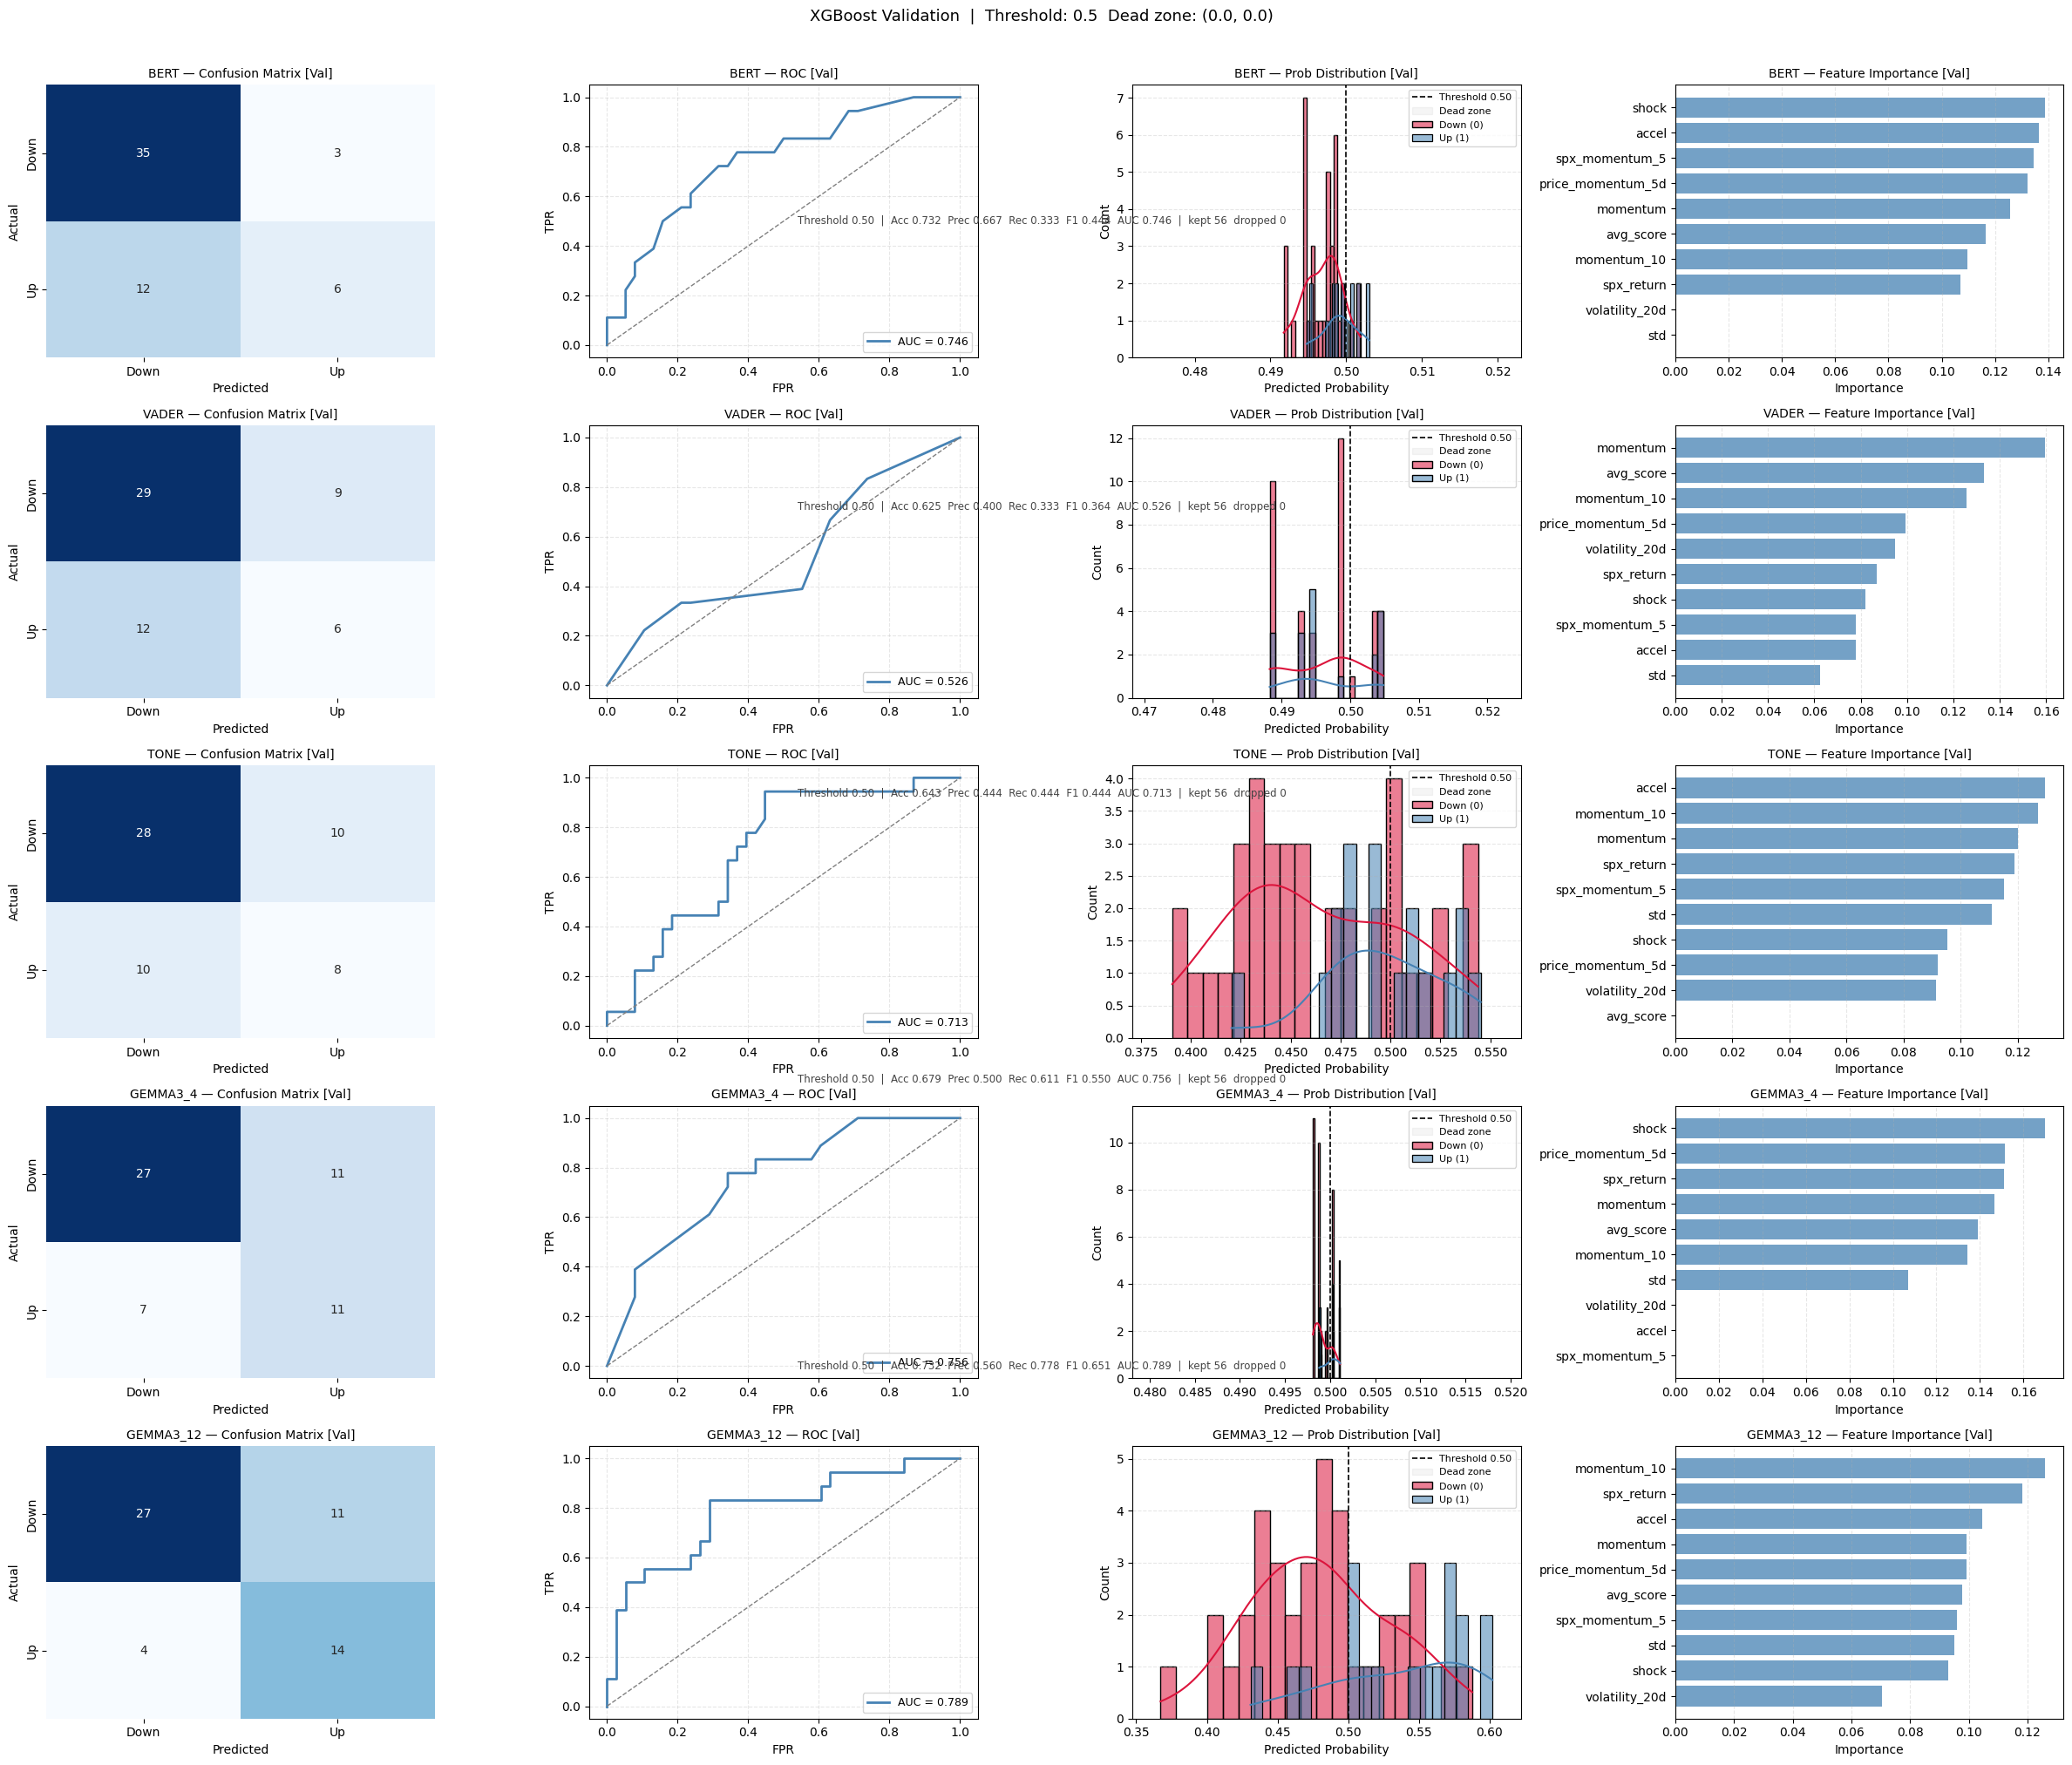

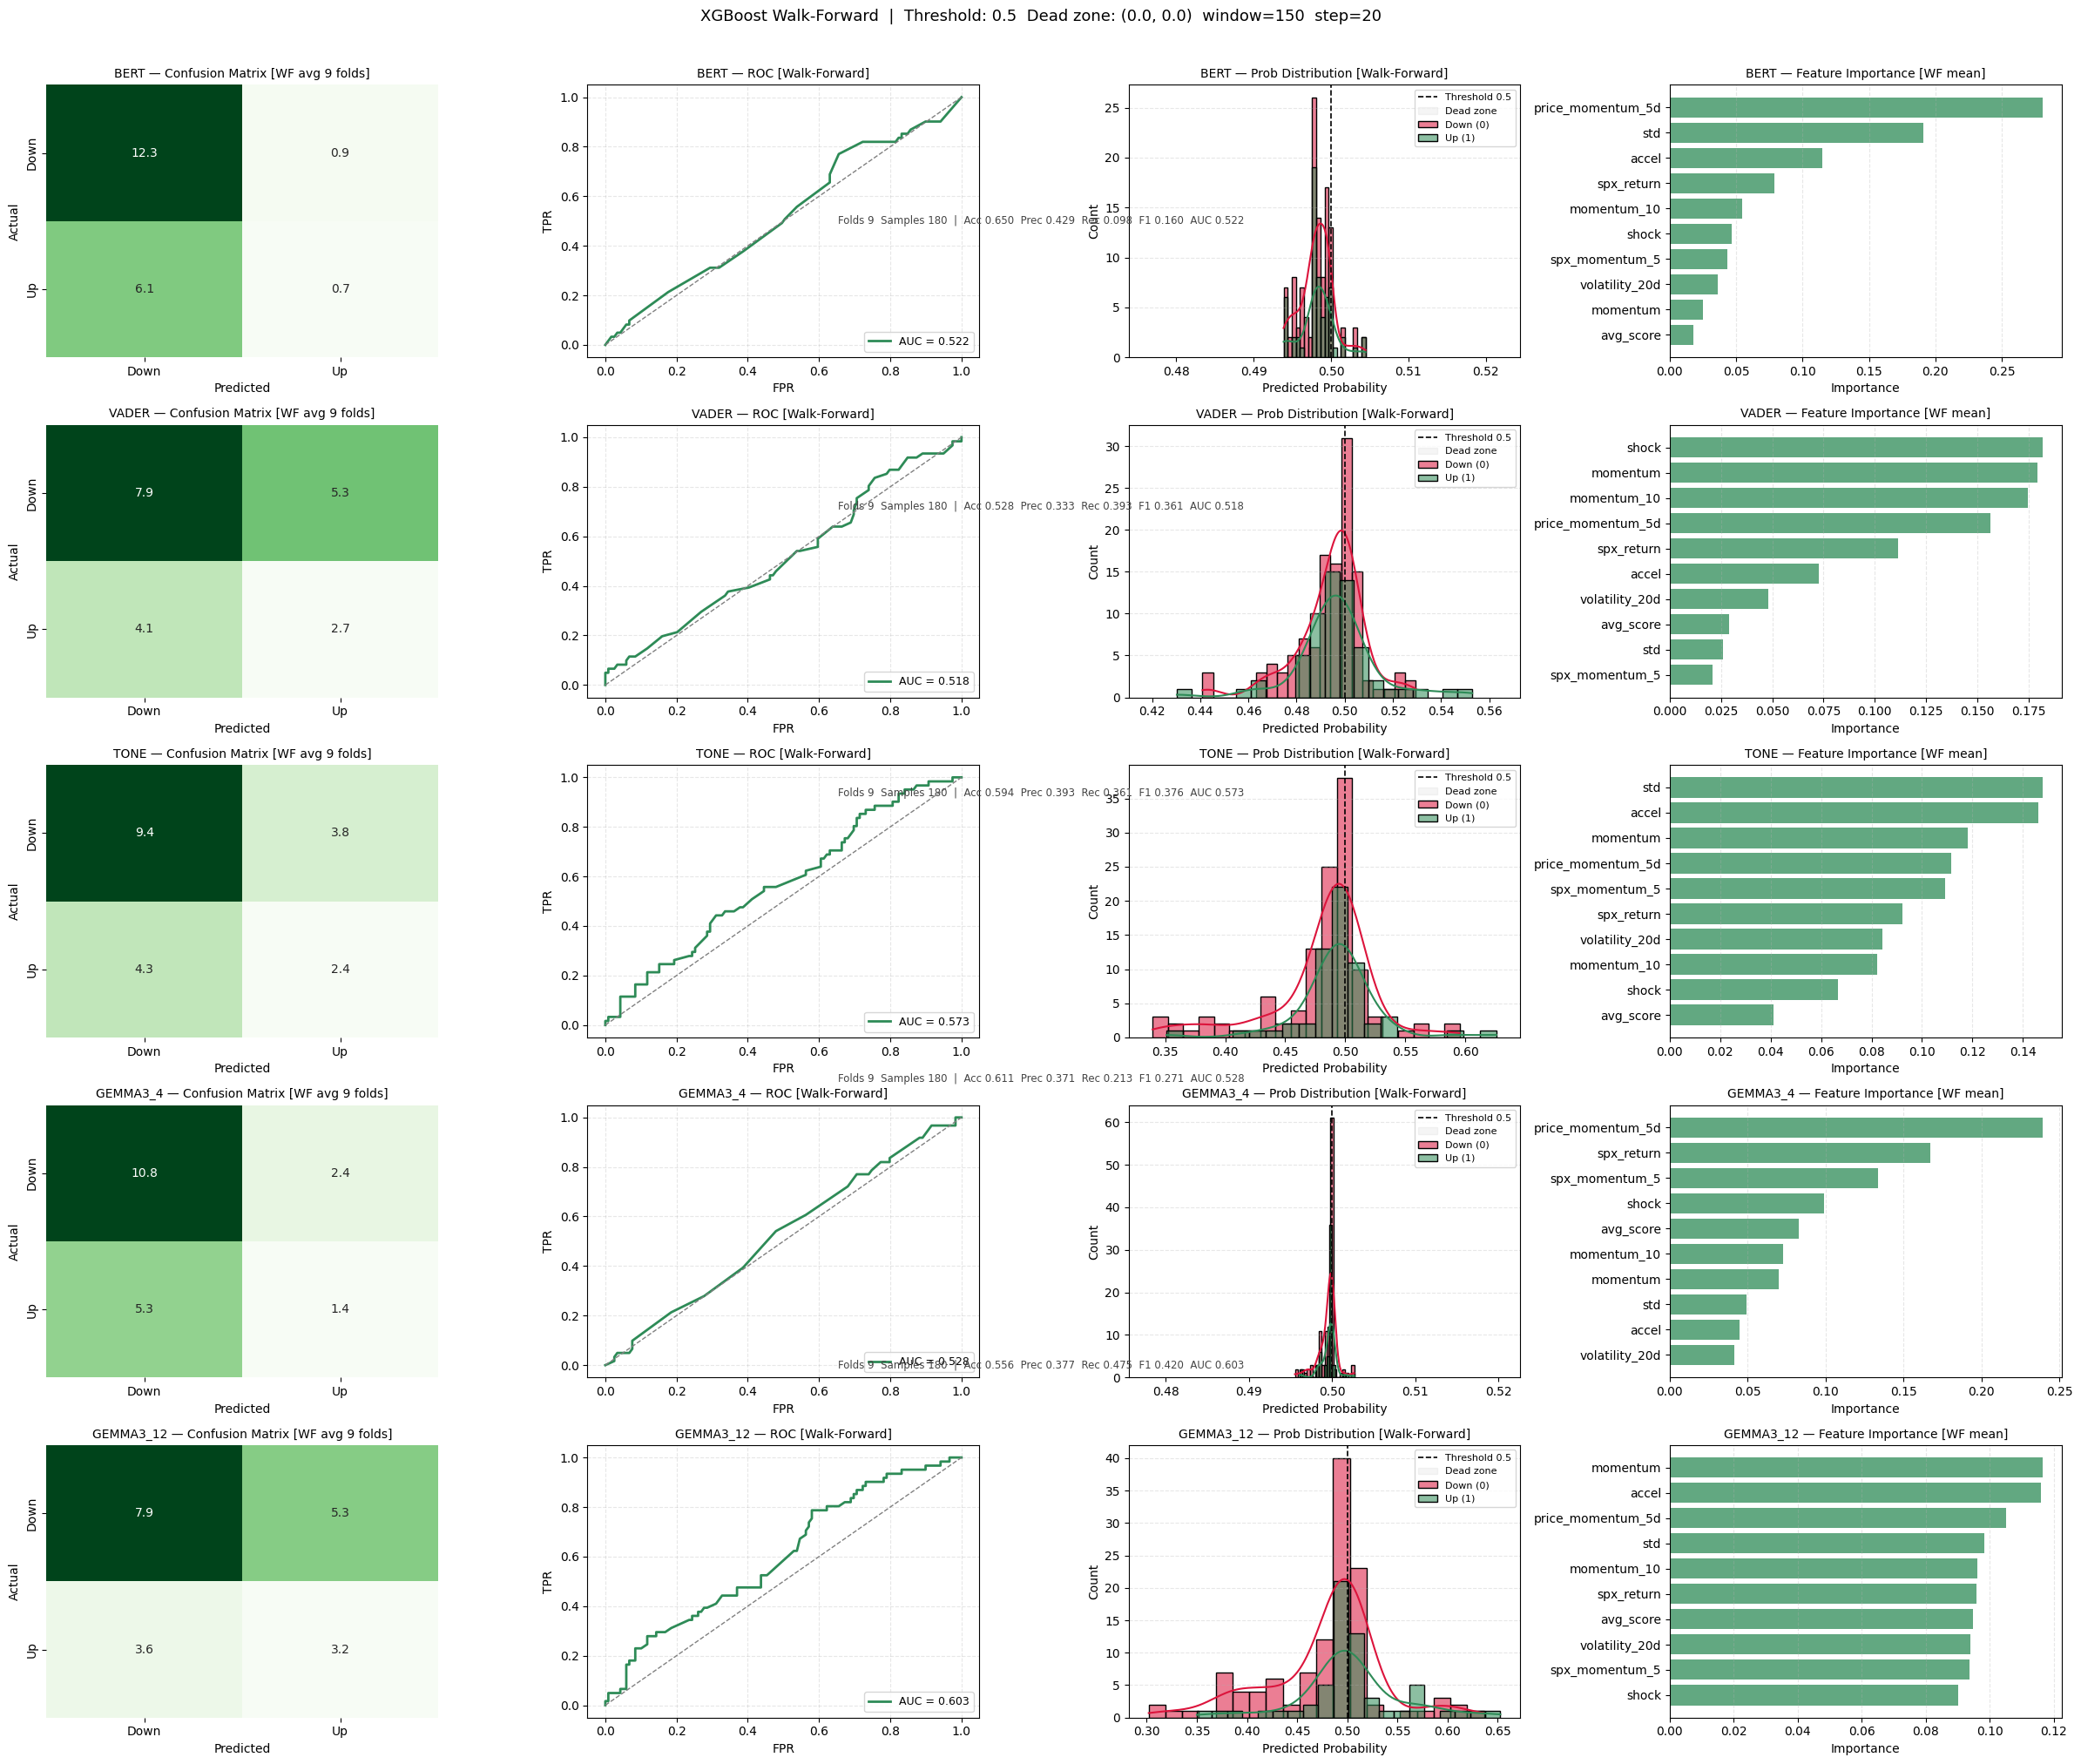

In [110]:
def plot_combined_diagnostics(
    models_dict: dict,
    splits_dict: dict,
    thresholds: dict,
    features: list[str],
    target_col: str,
    split_key: int = 1,
    val_cmap: str = "Blues",
    val_color: str = "steelblue",
    wf_cmap: str = "Greens",
    wf_color: str = "seagreen",
    title_suffix: str = "Validation",
) -> None:
    """
    Two separate diagnostic figures — one for validation, one for walk-forward.
    Each has one row per model and 4 panels:
    [Confusion Matrix | ROC | Prob Distribution (zoomed) | Feature Importance]
    """
    model_names = list(models_dict.keys())
    n = len(model_names)

    # ── Collect walk-forward data for all models first ────────────────────────
    wf_data = {}
    for name in model_names:
        full_df = (
            build_model_df(df_merged_models[name], name)
            .dropna(subset=features + [target_col])
            .sort_values("date")
            .reset_index(drop=True)
        )

        nf = len(full_df)
        all_preds, fold_cms, imp_list = [], [], []

        for start in range(0, nf - WF_TRAIN_WINDOW - WF_STEP + 1, WF_STEP):
            train_end = start + WF_TRAIN_WINDOW
            test_end  = train_end + WF_STEP

            df_tr = full_df.iloc[start:train_end]
            df_te = full_df.iloc[train_end:test_end]

            y_tr = df_tr[target_col].astype(int)
            y_te = df_te[target_col].astype(int)

            if y_tr.nunique() < 2:
                continue

            mp = {**validation_results[name]["best_params"], "eval_metric": "logloss"}
            if SCALE_POS_WEIGHT:
                neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
                mp["scale_pos_weight"] = neg / max(pos, 1)

            wf_model = XGBClassifier(**mp, random_state=42, early_stopping_rounds=20)
            wf_model.fit(
                df_tr[features].values, y_tr.values,
                eval_set=[(df_te[features].values, y_te.values)],
                verbose=False,
            )

            y_prob_raw_w = wf_model.predict_proba(df_te[features].values)[:, 1]
            y_prob_w, y_true_w, y_pred_w, _, _ = apply_dead_zone(
                y_prob_raw_w, y_te.values, float(DECISION_THRESHOLD), DZ_LOW, DZ_HIGH
            )

            if len(y_true_w) == 0:
                continue

            all_preds.append({"y_true": y_true_w, "y_pred": y_pred_w, "y_prob": y_prob_w})
            imp_list.append(wf_model.feature_importances_)
            fold_cms.append(confusion_matrix(y_true_w, y_pred_w, labels=[0, 1]))

        wf_data[name] = {
            "all_preds": all_preds,
            "fold_cms":  fold_cms,
            "imp_mean":  np.mean(imp_list, axis=0) if imp_list else np.zeros(len(features)),
        }

    # ── Figure 1: Validation ──────────────────────────────────────────────────
    fig_v, axes_v = plt.subplots(n, 4, figsize=(24, n * 4))
    fig_v.subplots_adjust(hspace=0.45, wspace=0.35)
    if n == 1:
        axes_v = axes_v[np.newaxis, :]

    for row, name in enumerate(model_names):
        model     = models_dict[name]
        df_split  = splits_dict[name][split_key]
        threshold = thresholds.get(name, 0.5)

        X_val      = df_split[features].values
        y_true_raw = df_split[target_col].astype(int).values
        y_prob_raw = model.predict_proba(X_val)[:, 1]

        y_prob_v, y_true_v, y_pred_v, n_kept_v, n_dropped_v = apply_dead_zone(
            y_prob_raw, y_true_raw, threshold, DZ_LOW, DZ_HIGH
        )

        ax_cm, ax_roc, ax_prob, ax_imp = axes_v[row]

        # Feature importance
        feat_df = (
            pd.DataFrame({"feature": features, "importance": model.feature_importances_})
            .sort_values("importance", ascending=True)
            .tail(12)
        )
        ax_imp.barh(feat_df["feature"], feat_df["importance"], color=val_color, alpha=0.75)
        ax_imp.set_title(f"{name.upper()} — Feature Importance [Val]", fontsize=10)
        ax_imp.set_xlabel("Importance")
        ax_imp.grid(axis="x", linestyle="--", alpha=0.3)

        if len(y_true_v) == 0:
            for ax, ttl in [(ax_cm, "Confusion Matrix"), (ax_roc, "ROC"), (ax_prob, "Probs")]:
                ax.set_title(f"{name.upper()} — {ttl} [Val]", fontsize=10)
                ax.text(0.5, 0.5, "No samples after dead-zone filter",
                        ha="center", va="center", color="gray", transform=ax.transAxes)
                ax.axis("off")
            continue

        # Confusion matrix
        cm = confusion_matrix(y_true_v, y_pred_v, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap=val_cmap, ax=ax_cm,
                    xticklabels=["Down", "Up"], yticklabels=["Down", "Up"], cbar=False)
        ax_cm.set_title(f"{name.upper()} — Confusion Matrix [Val]", fontsize=10)
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")

        # ROC
        if len(np.unique(y_true_v)) >= 2:
            fpr, tpr, _ = roc_curve(y_true_v, y_prob_v)
            ax_roc.plot(fpr, tpr, color=val_color, linewidth=2, label=f"AUC = {auc(fpr, tpr):.3f}")
            ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
            ax_roc.legend(loc="lower right", fontsize=9)
        else:
            ax_roc.text(0.5, 0.5, "Single class — ROC undefined",
                        ha="center", va="center", color="gray", transform=ax_roc.transAxes)
        ax_roc.set_title(f"{name.upper()} — ROC [Val]", fontsize=10)
        ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
        ax_roc.grid(linestyle="--", alpha=0.3)

        # Probability distribution — zoomed to data range
        for cls, lbl, c in [(0, "Down (0)", "crimson"), (1, "Up (1)", val_color)]:
            sub = y_prob_v[y_true_v == cls]
            if len(sub) > 0:
                sns.histplot(sub, bins=20, color=c, alpha=0.55, ax=ax_prob,
                             label=lbl, kde=len(sub) > 5)
        ax_prob.axvline(threshold, color="black", linestyle="--",
                        linewidth=1.2, label=f"Threshold {threshold:.2f}")
        ax_prob.axvspan(DZ_LOW, DZ_HIGH, alpha=0.08, color="gray", label="Dead zone")
        ax_prob.set_title(f"{name.upper()} — Prob Distribution [Val]", fontsize=10)
        ax_prob.set_xlabel("Predicted Probability"); ax_prob.set_ylabel("Count")
        ax_prob.legend(fontsize=8)
        ax_prob.grid(axis="y", linestyle="--", alpha=0.3)
        p_min = max(0.0, y_prob_v.min() - 0.02)
        p_max = min(1.0, y_prob_v.max() + 0.02)
        ax_prob.set_xlim(p_min, p_max)

        # Row annotation
        metrics_v = metric_bundle(y_true_v, y_pred_v, y_prob_v)
        fig_v.text(
            0.5, axes_v[row, 0].get_position().y1 + 0.005,
            f"Threshold {threshold:.2f}  |  Acc {metrics_v['accuracy']:.3f}  "
            f"Prec {metrics_v['precision']:.3f}  Rec {metrics_v['recall']:.3f}  "
            f"F1 {metrics_v['f1']:.3f}  AUC {metrics_v['roc_auc']:.3f}  |  "
            f"kept {n_kept_v}  dropped {n_dropped_v}",
            ha="center", va="bottom", fontsize=8.5, color="#444", transform=fig_v.transFigure,
        )

    fig_v.suptitle(
        f"XGBoost Validation  |  Threshold: {DECISION_THRESHOLD}  "
        f"Dead zone: {THRESHOLD_DEAD_ZONE}",
        fontsize=13, y=1.01,
    )
    fig_v.tight_layout()
    plt.show()

    # ── Figure 2: Walk-Forward ────────────────────────────────────────────────
    fig_w, axes_w = plt.subplots(n, 4, figsize=(24, n * 4))
    fig_w.subplots_adjust(hspace=0.45, wspace=0.35)
    if n == 1:
        axes_w = axes_w[np.newaxis, :]

    for row, name in enumerate(model_names):
        ax_cm, ax_roc, ax_prob, ax_imp = axes_w[row]

        data      = wf_data[name]
        all_preds = data["all_preds"]
        fold_cms  = data["fold_cms"]
        imp_mean  = data["imp_mean"]

        if not all_preds:
            for ax, ttl in [(ax_cm, "Confusion Matrix"), (ax_roc, "ROC"),
                            (ax_prob, "Probs"), (ax_imp, "Importance")]:
                ax.set_title(f"{name.upper()} — {ttl} [WF]", fontsize=10)
                ax.text(0.5, 0.5, "No valid folds", ha="center", va="center",
                        color="gray", transform=ax.transAxes)
                ax.axis("off")
            continue

        y_true_all = np.concatenate([p["y_true"] for p in all_preds])
        y_pred_all = np.concatenate([p["y_pred"] for p in all_preds])
        y_prob_all = np.concatenate([p["y_prob"] for p in all_preds])

        # Confusion matrix (averaged)
        cm_avg = np.mean(fold_cms, axis=0)
        sns.heatmap(cm_avg, annot=True, fmt=".1f", cmap=wf_cmap, ax=ax_cm,
                    xticklabels=["Down", "Up"], yticklabels=["Down", "Up"], cbar=False)
        ax_cm.set_title(f"{name.upper()} — Confusion Matrix [WF avg {len(all_preds)} folds]", fontsize=10)
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")

        # ROC
        if len(np.unique(y_true_all)) >= 2:
            fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
            ax_roc.plot(fpr, tpr, color=wf_color, linewidth=2, label=f"AUC = {auc(fpr, tpr):.3f}")
            ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
            ax_roc.legend(loc="lower right", fontsize=9)
        else:
            ax_roc.text(0.5, 0.5, "Single class — ROC undefined",
                        ha="center", va="center", color="gray", transform=ax_roc.transAxes)
        ax_roc.set_title(f"{name.upper()} — ROC [Walk-Forward]", fontsize=10)
        ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
        ax_roc.grid(linestyle="--", alpha=0.3)

        # Probability distribution — zoomed to data range
        for cls, lbl, c in [(0, "Down (0)", "crimson"), (1, "Up (1)", wf_color)]:
            sub = y_prob_all[y_true_all == cls]
            if len(sub) > 0:
                sns.histplot(sub, bins=20, color=c, alpha=0.55, ax=ax_prob,
                             label=lbl, kde=len(sub) > 5)
        ax_prob.axvline(float(DECISION_THRESHOLD), color="black", linestyle="--",
                        linewidth=1.2, label=f"Threshold {DECISION_THRESHOLD}")
        ax_prob.axvspan(DZ_LOW, DZ_HIGH, alpha=0.08, color="gray", label="Dead zone")
        ax_prob.set_title(f"{name.upper()} — Prob Distribution [Walk-Forward]", fontsize=10)
        ax_prob.set_xlabel("Predicted Probability"); ax_prob.set_ylabel("Count")
        ax_prob.legend(fontsize=8)
        ax_prob.grid(axis="y", linestyle="--", alpha=0.3)
        p_min = max(0.0, y_prob_all.min() - 0.02)
        p_max = min(1.0, y_prob_all.max() + 0.02)
        ax_prob.set_xlim(p_min, p_max)

        # Mean feature importance
        feat_df_w = (
            pd.DataFrame({"feature": features, "importance": imp_mean})
            .sort_values("importance", ascending=True)
            .tail(12)
        )
        ax_imp.barh(feat_df_w["feature"], feat_df_w["importance"], color=wf_color, alpha=0.75)
        ax_imp.set_title(f"{name.upper()} — Feature Importance [WF mean]", fontsize=10)
        ax_imp.set_xlabel("Importance")
        ax_imp.grid(axis="x", linestyle="--", alpha=0.3)

        # Row annotation
        metrics_w = metric_bundle(y_true_all, y_pred_all, y_prob_all)
        fig_w.text(
            0.5, axes_w[row, 0].get_position().y1 + 0.005,
            f"Folds {len(all_preds)}  Samples {len(y_true_all)}  |  "
            f"Acc {metrics_w['accuracy']:.3f}  Prec {metrics_w['precision']:.3f}  "
            f"Rec {metrics_w['recall']:.3f}  F1 {metrics_w['f1']:.3f}  "
            f"AUC {metrics_w['roc_auc']:.3f}",
            ha="center", va="bottom", fontsize=8.5, color="#444", transform=fig_w.transFigure,
        )

    fig_w.suptitle(
        f"XGBoost Walk-Forward  |  Threshold: {DECISION_THRESHOLD}  "
        f"Dead zone: {THRESHOLD_DEAD_ZONE}  window={WF_TRAIN_WINDOW}  step={WF_STEP}",
        fontsize=13, y=1.01,
    )
    fig_w.tight_layout()
    plt.show()


plot_combined_diagnostics(
    xgb_models, splits, best_thresholds,
    XGB_FEATURES, TARGET_COL,
    split_key=1,
    val_cmap="Blues",  val_color="steelblue",
    wf_cmap="Greens",  wf_color="seagreen",
    title_suffix="Validation",
)

---
## 10 · Holdout Test Evaluation


HOLDOUT TEST — Threshold: 0.5  Dead zone: (0.0, 0.0)
Model          Acc    Prec     Rec      F1     AUC    Kept    Drop
-----------------------------------------------------------------
bert         0.562   0.333   0.143   0.200   0.504      73       0
vader        0.466   0.366   0.536   0.435   0.479      73       0
tone         0.603   0.480   0.429   0.453   0.504      73       0
gemma3_4     0.575   0.440   0.393   0.415   0.494      73       0
gemma3_12    0.507   0.375   0.429   0.400   0.447      73       0


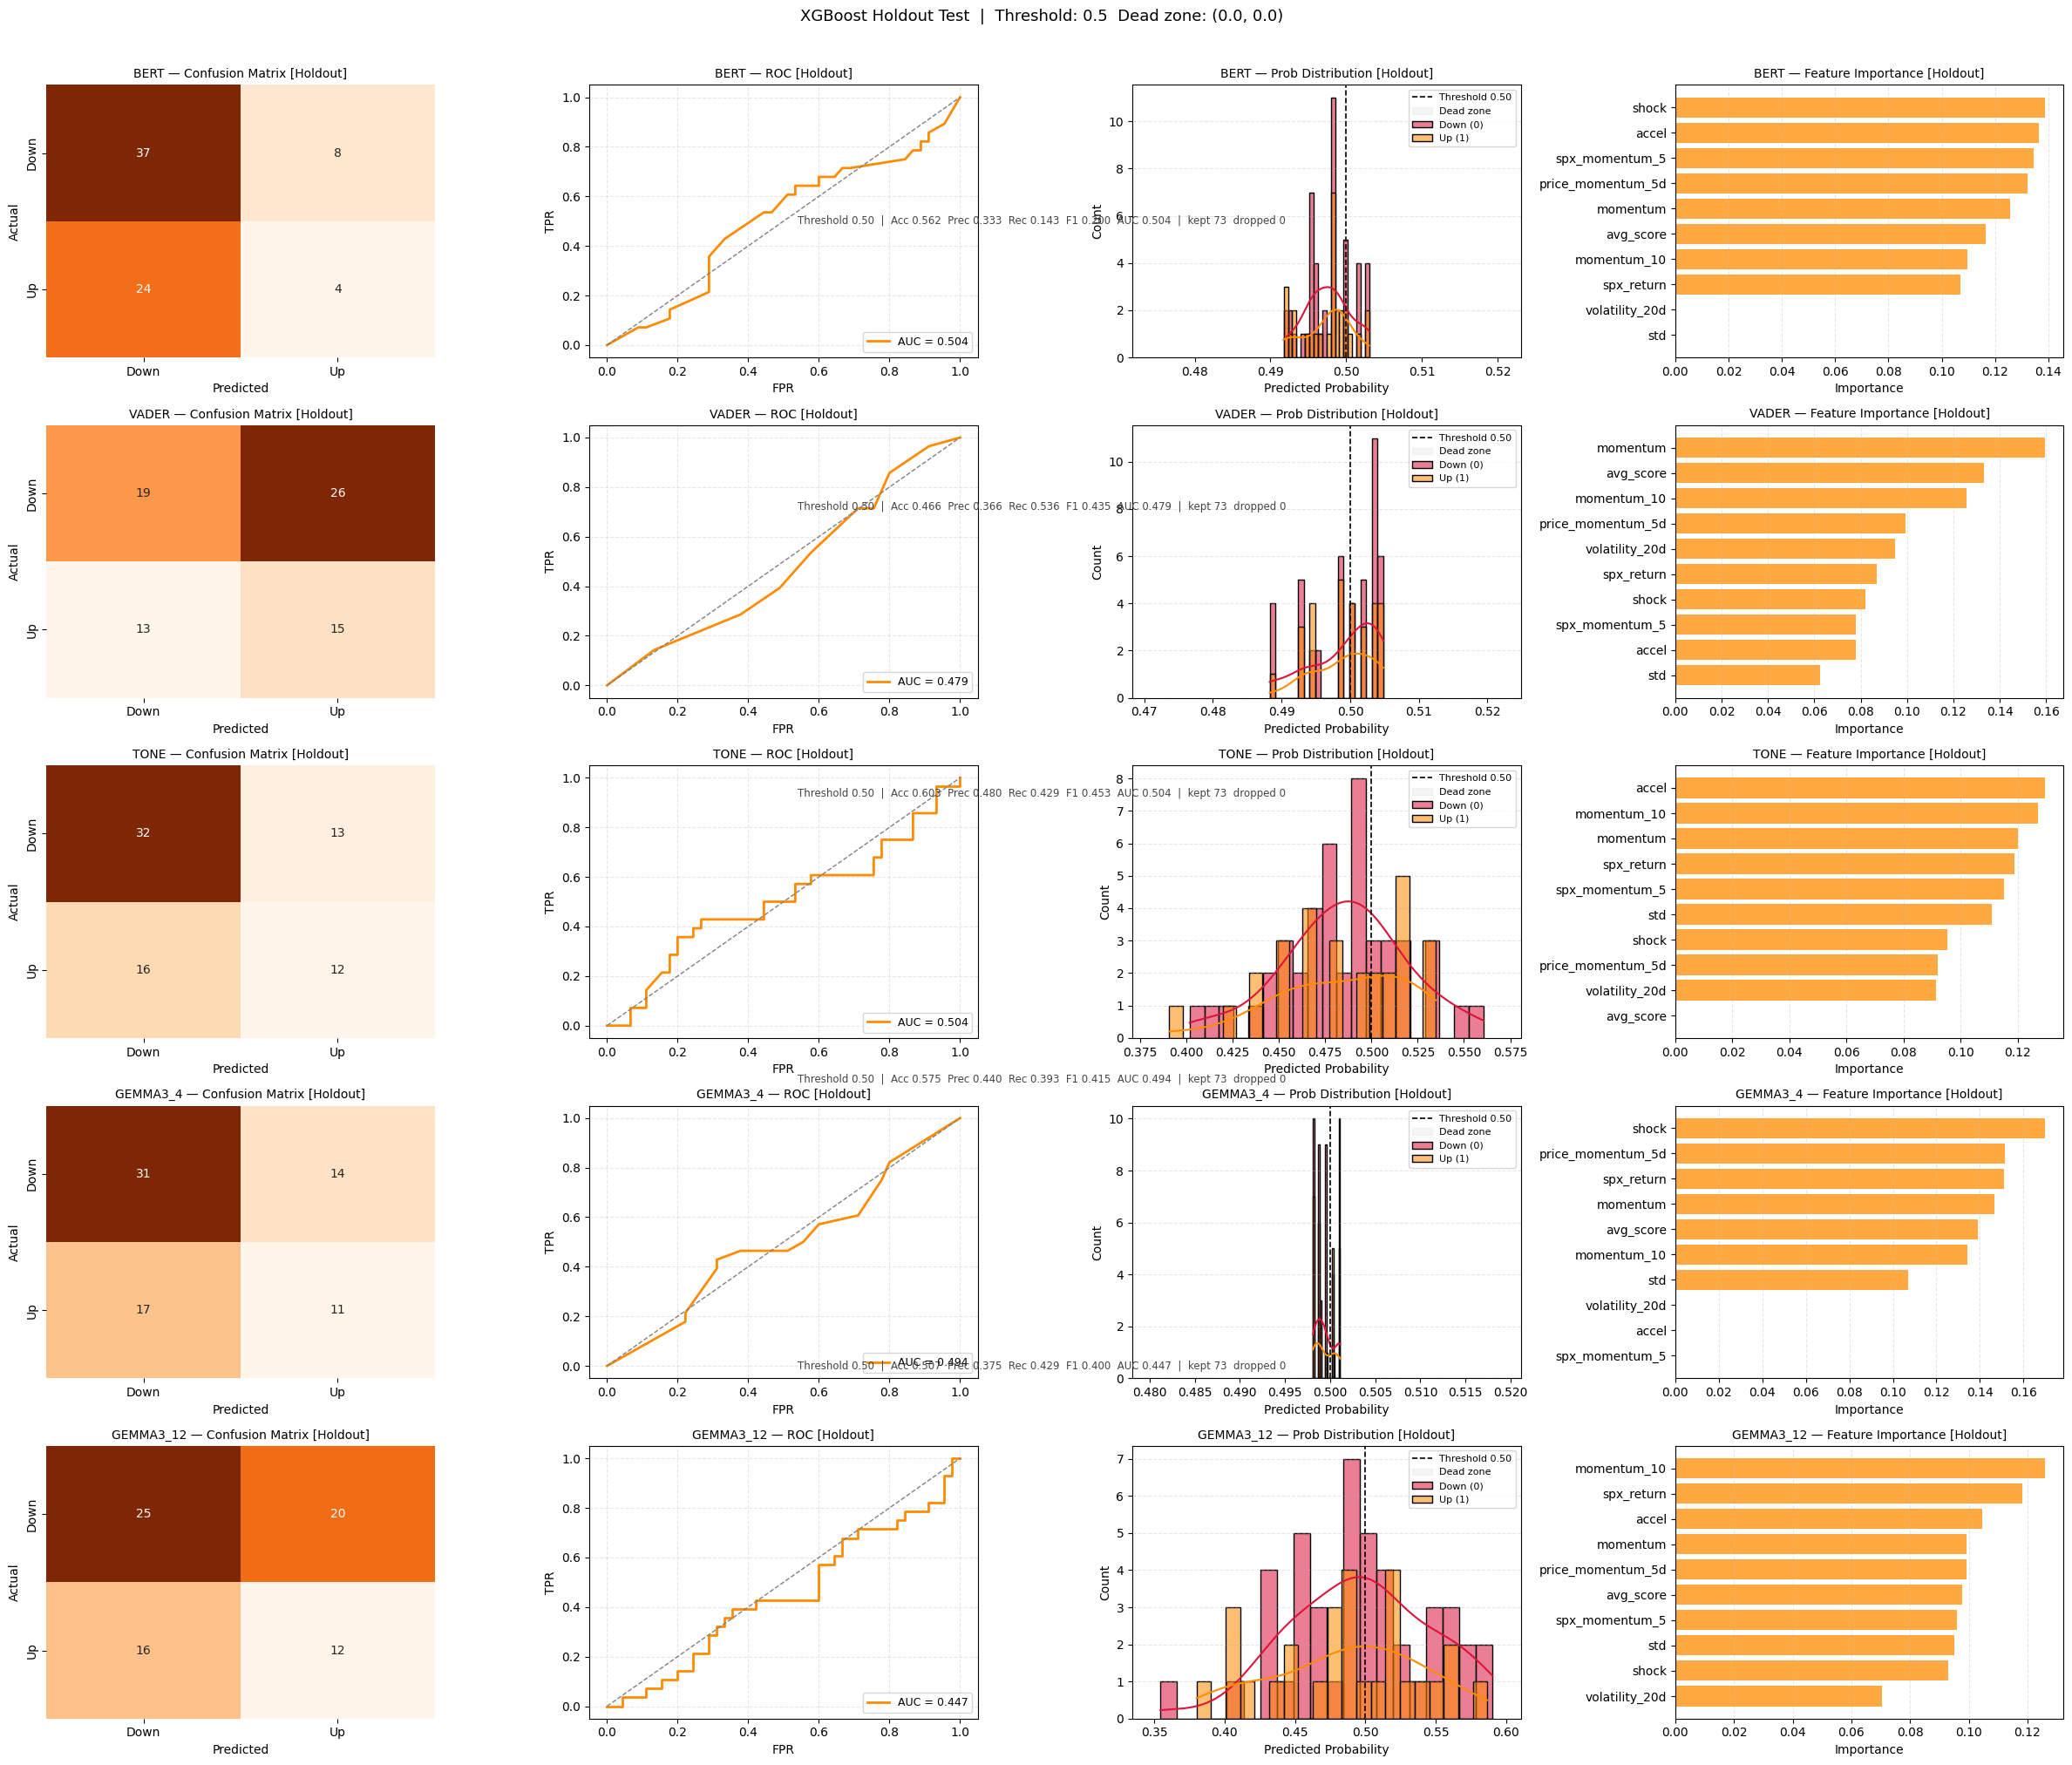

In [111]:
frozen_models = {name: joblib.load(os.path.join(SESSION_LOG_DIR, f"xgb_{name}_frozen.pkl")) for name in SENTIMENT_MODELS}

holdout_results = {}
for name in SENTIMENT_MODELS:
    _, _, df_test = splits[name]
    y_prob_raw = frozen_models[name].predict_proba(df_test[XGB_FEATURES].values)[:, 1]
    y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
        y_prob_raw, df_test[TARGET_COL].astype(int).values,
        float(DECISION_THRESHOLD), DZ_LOW, DZ_HIGH,
    )
    holdout_results[name] = dict(
        y_prob=y_prob, y_true=y_true, y_pred=y_pred,
        n_kept=n_kept, n_dropped=n_dropped,
        metrics=metric_bundle(y_true, y_pred, y_prob),
    )

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"HOLDOUT TEST — Threshold: {DECISION_THRESHOLD}  Dead zone: {THRESHOLD_DEAD_ZONE}")
print(f"{'='*65}")
print(f"{'Model':<10} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Kept':>7} {'Drop':>7}")
print("-" * 65)
for name, res in holdout_results.items():
    m = res["metrics"]
    print(f"{name:<10} {m['accuracy']:>7.3f} {m['precision']:>7.3f} "
          f"{m['recall']:>7.3f} {m['f1']:>7.3f} {m['roc_auc']:>7.3f} "
          f"{res['n_kept']:>7} {res['n_dropped']:>7}")

# ── Holdout diagnostics — validation-style plot in orange ────────────────────
def plot_holdout_diagnostics(
    models_dict: dict,
    splits_dict: dict,
    features: list[str],
    target_col: str,
    cmap: str = "Oranges",
    color: str = "darkorange",
) -> None:
    """4-panel holdout diagnostic grid — one row per model."""
    model_names = list(models_dict.keys())
    n = len(model_names)
    fig, axes = plt.subplots(n, 4, figsize=(24, n * 4))
    fig.subplots_adjust(hspace=0.45, wspace=0.35)
    if n == 1:
        axes = axes[np.newaxis, :]

    threshold = float(DECISION_THRESHOLD)

    for row, name in enumerate(model_names):
        model    = models_dict[name]
        _, _, df_test = splits_dict[name]

        X          = df_test[features].values
        y_true_raw = df_test[target_col].astype(int).values
        y_prob_raw = model.predict_proba(X)[:, 1]

        y_prob, y_true, y_pred, n_kept, n_dropped = apply_dead_zone(
            y_prob_raw, y_true_raw, threshold, DZ_LOW, DZ_HIGH
        )

        ax_cm, ax_roc, ax_prob, ax_imp = axes[row]

        # Feature importance
        feat_df = (
            pd.DataFrame({"feature": features, "importance": model.feature_importances_})
            .sort_values("importance", ascending=True)
            .tail(12)
        )
        ax_imp.barh(feat_df["feature"], feat_df["importance"], color=color, alpha=0.75)
        ax_imp.set_title(f"{name.upper()} — Feature Importance [Holdout]", fontsize=10)
        ax_imp.set_xlabel("Importance")
        ax_imp.grid(axis="x", linestyle="--", alpha=0.3)

        if len(y_true) == 0:
            for ax, ttl in [(ax_cm, "Confusion Matrix"), (ax_roc, "ROC"), (ax_prob, "Probs")]:
                ax.set_title(f"{name.upper()} — {ttl} [Holdout]", fontsize=10)
                ax.text(0.5, 0.5, "No samples after dead-zone filter",
                        ha="center", va="center", color="gray", transform=ax.transAxes)
                ax.axis("off")
            continue

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax_cm,
                    xticklabels=["Down", "Up"], yticklabels=["Down", "Up"], cbar=False)
        ax_cm.set_title(f"{name.upper()} — Confusion Matrix [Holdout]", fontsize=10)
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")

        # ROC
        if len(np.unique(y_true)) >= 2:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"AUC = {auc(fpr, tpr):.3f}")
            ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
            ax_roc.legend(loc="lower right", fontsize=9)
        else:
            ax_roc.text(0.5, 0.5, "Single class — ROC undefined",
                        ha="center", va="center", color="gray", transform=ax_roc.transAxes)
        ax_roc.set_title(f"{name.upper()} — ROC [Holdout]", fontsize=10)
        ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
        ax_roc.grid(linestyle="--", alpha=0.3)

        # Probability distribution — zoomed to data range
        for cls, lbl, c in [(0, "Down (0)", "crimson"), (1, "Up (1)", color)]:
            sub = y_prob[y_true == cls]
            if len(sub) > 0:
                sns.histplot(sub, bins=20, color=c, alpha=0.55, ax=ax_prob,
                             label=lbl, kde=len(sub) > 5)
        ax_prob.axvline(threshold, color="black", linestyle="--",
                        linewidth=1.2, label=f"Threshold {threshold:.2f}")
        ax_prob.axvspan(DZ_LOW, DZ_HIGH, alpha=0.08, color="gray", label="Dead zone")
        ax_prob.set_title(f"{name.upper()} — Prob Distribution [Holdout]", fontsize=10)
        ax_prob.set_xlabel("Predicted Probability"); ax_prob.set_ylabel("Count")
        ax_prob.legend(fontsize=8)
        ax_prob.grid(axis="y", linestyle="--", alpha=0.3)
        p_min = max(0.0, y_prob.min() - 0.02)
        p_max = min(1.0, y_prob.max() + 0.02)
        ax_prob.set_xlim(p_min, p_max)

        # Row annotation
        metrics = metric_bundle(y_true, y_pred, y_prob)
        fig.text(
            0.5, axes[row, 0].get_position().y1 + 0.005,
            f"Threshold {threshold:.2f}  |  Acc {metrics['accuracy']:.3f}  "
            f"Prec {metrics['precision']:.3f}  Rec {metrics['recall']:.3f}  "
            f"F1 {metrics['f1']:.3f}  AUC {metrics['roc_auc']:.3f}  |  "
            f"kept {n_kept}  dropped {n_dropped}",
            ha="center", va="bottom", fontsize=8.5, color="#444", transform=fig.transFigure,
        )

    fig.suptitle(
        f"XGBoost Holdout Test  |  Threshold: {DECISION_THRESHOLD}  "
        f"Dead zone: {THRESHOLD_DEAD_ZONE}",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    plt.show()


plot_holdout_diagnostics(
    frozen_models, splits, XGB_FEATURES, TARGET_COL,
    cmap="Oranges", color="darkorange",
)

---
## 11 · Trading Simulation

  Rows: 50  |  2026-02-03 → 2026-04-15
  Long: 18d  Short: 32d  Flat: 0d  y_prob: 0.4115–0.5606
  Long  correct: 9/18 (50.0%)
  Short correct: 11/31 (35.5%)

  Normal long 1.046 vs flipped 1.054 — ✗ market drift
  Normal L/S 0.971 vs flipped 1.000  |  Market 1.103


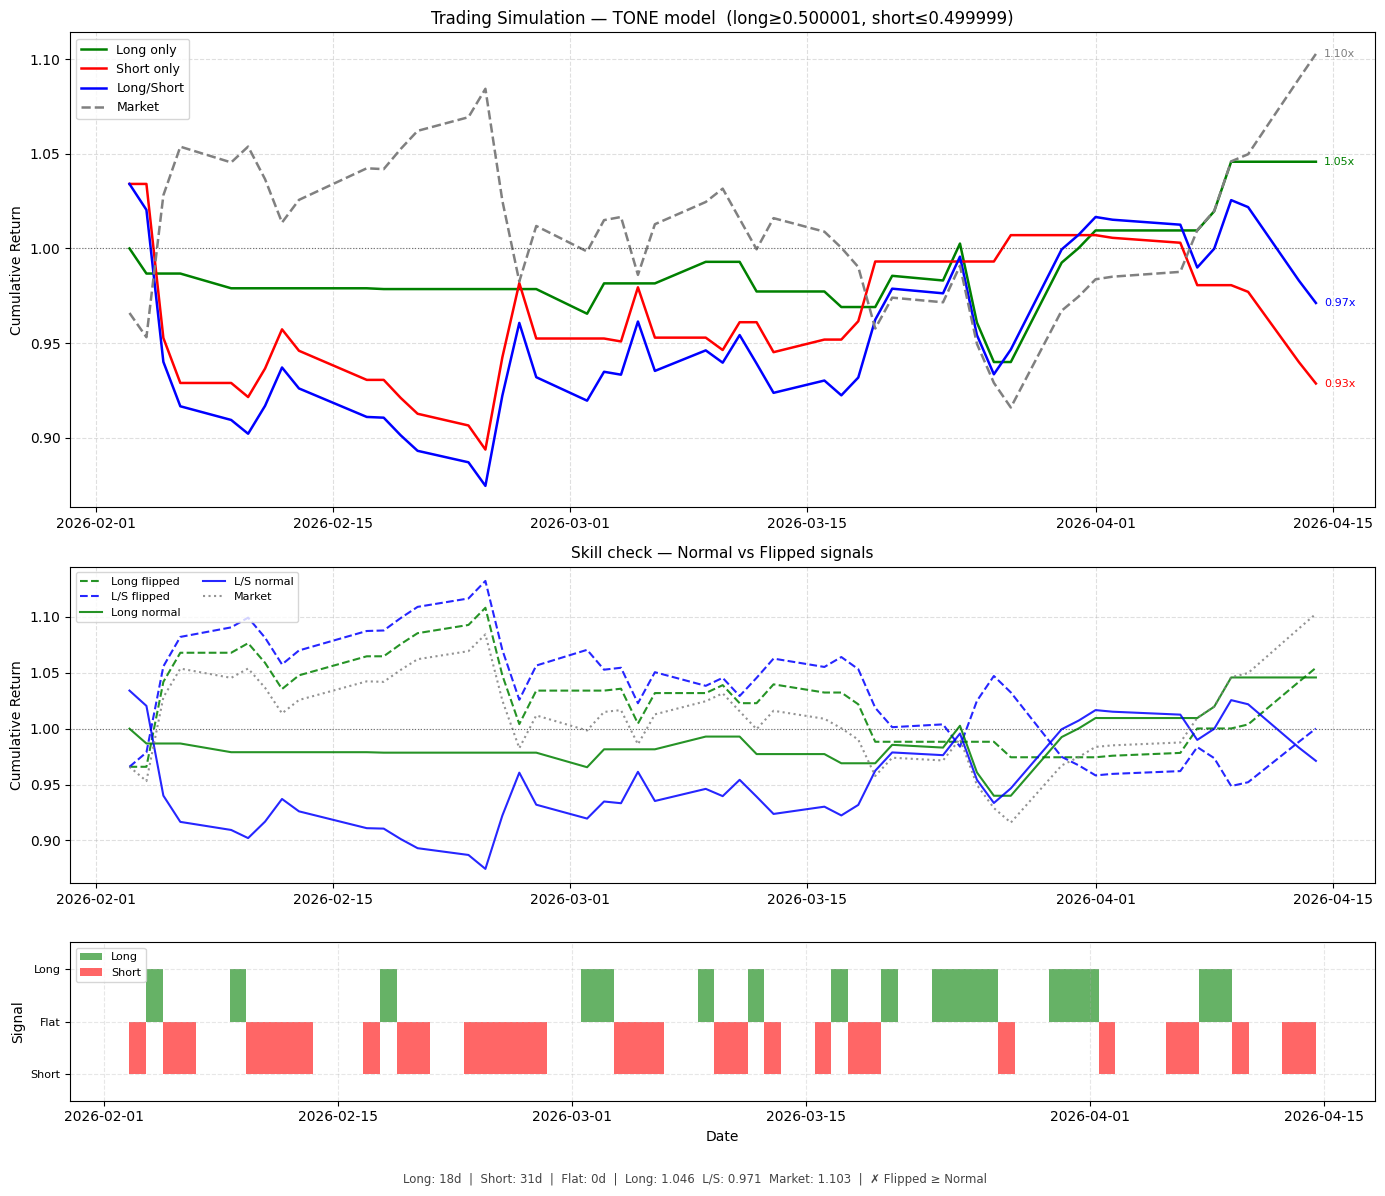

In [116]:

import yfinance as yf


def get_simulation_returns(date_from: str, date_to: str, ticker: str = TICKER) -> pd.DataFrame:
    """Pull clean daily returns from yfinance — only real trading days, no weekends."""
    raw = yf.download(ticker, start=date_from, end=date_to, auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw = raw.reset_index()
    raw.columns = raw.columns.str.lower()
    if raw["date"].dt.tz is not None:
        raw["date"] = raw["date"].dt.tz_convert(None)
    raw["date"]   = pd.to_datetime(raw["date"]).dt.normalize()
    raw["return"] = raw["close"].pct_change()
    return raw[["date", "return"]].dropna().reset_index(drop=True)


def simulate_trading(
    model,
    df_test: pd.DataFrame,
    features: list[str],
    long_thresh: float = LONG_THRESHOLD,
    short_thresh: float = SHORT_THRESHOLD,
) -> pd.DataFrame:
    """
    Simulate long-only, short-only, and long/short strategies on the test set.
    Uses fresh yfinance data to guarantee only real trading days are used.
    Shifts returns by one day to correctly align signal with next-day outcome.
    """
    df_test = df_test.copy()
    df_test["date"] = pd.to_datetime(df_test["date"]).dt.normalize()

    date_from    = df_test["date"].min().strftime("%Y-%m-%d")
    date_to      = (df_test["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    real_returns = get_simulation_returns(date_from, date_to)

    # Keep only real trading days then merge returns
    df_test = df_test[df_test["date"].isin(set(real_returns["date"]))].reset_index(drop=True)
    sim     = df_test.merge(real_returns, on="date", how="inner")
    sim     = sim.dropna(subset=["return"] + features).reset_index(drop=True)

    print(f"  Rows: {len(sim)}  |  {sim['date'].min().date()} → {sim['date'].max().date()}")

    sim["y_prob"] = model.predict_proba(sim[features].values)[:, 1]

    # Signals
    sim["signal_long"]       = (sim["y_prob"] >= long_thresh).astype(int)
    sim["signal_short"]      = -(sim["y_prob"] <= short_thresh).astype(int)
    sim["signal_ls"]         = sim["signal_long"] + sim["signal_short"]
    sim["signal_long_flip"]  = (sim["y_prob"] <= short_thresh).astype(int)
    sim["signal_short_flip"] = -(sim["y_prob"] >= long_thresh).astype(int)
    sim["signal_ls_flip"]    = sim["signal_long_flip"] + sim["signal_short_flip"]

    print(f"  Long: {sim['signal_long'].sum()}d  "
          f"Short: {(sim['signal_short']==-1).sum()}d  "
          f"Flat: {(sim['signal_ls']==0).sum()}d  "
          f"y_prob: {sim['y_prob'].min():.4f}–{sim['y_prob'].max():.4f}")

    # Shift returns — today's signal earns tomorrow's return
    sim["return"] = sim["return"].shift(-1)
    sim = sim.iloc[:-1].reset_index(drop=True)

    # Cumulative returns — normal and flipped
    for col, sig in [
        ("cum_long",       "signal_long"),
        ("cum_short",      "signal_short"),
        ("cum_ls",         "signal_ls"),
        ("cum_long_flip",  "signal_long_flip"),
        ("cum_short_flip", "signal_short_flip"),
        ("cum_ls_flip",    "signal_ls_flip"),
    ]:
        sim[col] = (1 + sim[sig] * sim["return"]).cumprod()
    sim["cum_market"] = (1 + sim["return"]).cumprod()

    # Hit rate
    for label, mask, direction in [
        ("Long ",  sim["signal_long"] == 1,   sim["return"] > 0),
        ("Short",  sim["signal_short"] == -1, sim["return"] < 0),
    ]:
        if mask.sum() > 0:
            print(f"  {label} correct: {(mask & direction).sum()}/{mask.sum()} "
                  f"({(mask & direction).sum() / mask.sum():.1%})")

    # Skill check
    skill = sim["cum_long"].iloc[-1] > sim["cum_long_flip"].iloc[-1]
    print(f"\n  Normal long {sim['cum_long'].iloc[-1]:.3f} vs "
          f"flipped {sim['cum_long_flip'].iloc[-1]:.3f} — "
          f"{'✓ signal present' if skill else '✗ market drift'}")
    print(f"  Normal L/S {sim['cum_ls'].iloc[-1]:.3f} vs "
          f"flipped {sim['cum_ls_flip'].iloc[-1]:.3f}  |  "
          f"Market {sim['cum_market'].iloc[-1]:.3f}")

    return sim


def plot_trading_simulation(sim: pd.DataFrame, title: str = "") -> None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                             gridspec_kw={"height_ratios": [3, 2, 1]})
    ax_ret, ax_flip, ax_sig = axes

    # Cumulative returns
    for col, lbl, c, ls in [
        ("cum_long",   "Long only",  "green", "-"),
        ("cum_short",  "Short only", "red",   "-"),
        ("cum_ls",     "Long/Short", "blue",  "-"),
        ("cum_market", "Market",     "gray",  "--"),
    ]:
        ax_ret.plot(sim["date"], sim[col], label=lbl, color=c, linestyle=ls, linewidth=1.8)
        ax_ret.annotate(f"{sim[col].iloc[-1]:.2f}x",
                        xy=(sim["date"].iloc[-1], sim[col].iloc[-1]),
                        xytext=(6, 0), textcoords="offset points",
                        fontsize=8, color=c, va="center")
    ax_ret.axhline(1.0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax_ret.set_title(title or "Trading Simulation", fontsize=12)
    ax_ret.set_ylabel("Cumulative Return")
    ax_ret.legend(loc="upper left", fontsize=9)
    ax_ret.grid(True, linestyle="--", alpha=0.4)

    # Skill check panel
    for col, lbl, c, ls in [
        ("cum_long_flip", "Long flipped", "green", "--"),
        ("cum_ls_flip",   "L/S flipped",  "blue",  "--"),
        ("cum_long",      "Long normal",  "green", "-"),
        ("cum_ls",        "L/S normal",   "blue",  "-"),
        ("cum_market",    "Market",       "gray",  ":"),
    ]:
        ax_flip.plot(sim["date"], sim[col], label=lbl, color=c,
                     linestyle=ls, linewidth=1.5, alpha=0.85)
    ax_flip.axhline(1.0, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax_flip.set_title("Skill check — Normal vs Flipped signals", fontsize=11)
    ax_flip.set_ylabel("Cumulative Return")
    ax_flip.legend(loc="upper left", fontsize=8, ncol=2)
    ax_flip.grid(True, linestyle="--", alpha=0.4)

    # Signal bars
    ax_sig.bar(sim["date"], sim["signal_long"],  color="green", alpha=0.6, width=1, label="Long")
    ax_sig.bar(sim["date"], sim["signal_short"], color="red",   alpha=0.6, width=1, label="Short")
    ax_sig.set_ylim(-1.5, 1.5)
    ax_sig.set_yticks([-1, 0, 1])
    ax_sig.set_yticklabels(["Short", "Flat", "Long"], fontsize=8)
    ax_sig.set_xlabel("Date"); ax_sig.set_ylabel("Signal")
    ax_sig.legend(loc="upper left", fontsize=8)
    ax_sig.grid(True, linestyle="--", alpha=0.3)

    skill = "✓ Normal > Flipped" if sim["cum_long"].iloc[-1] > sim["cum_long_flip"].iloc[-1] \
            else "✗ Flipped ≥ Normal"
    fig.text(
        0.5, 0.01,
        f"Long: {sim['signal_long'].sum()}d  |  "
        f"Short: {(sim['signal_short']==-1).sum()}d  |  "
        f"Flat: {(sim['signal_ls']==0).sum()}d  |  "
        f"Long: {sim['cum_long'].iloc[-1]:.3f}  "
        f"L/S: {sim['cum_ls'].iloc[-1]:.3f}  "
        f"Market: {sim['cum_market'].iloc[-1]:.3f}  |  {skill}",
        ha="center", fontsize=8.5, color="#444",
    )
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
sim_model_name = SIM_MODEL if SIM_MODEL in frozen_models else SENTIMENT_MODELS[0]
_, _, df_test_sim_src = splits[sim_model_name]

sim = simulate_trading(frozen_models[sim_model_name], df_test_sim_src, XGB_FEATURES)

plot_trading_simulation(
    sim,
    title=f"Trading Simulation — {sim_model_name.upper()} model  "
          f"(long≥{LONG_THRESHOLD}, short≤{SHORT_THRESHOLD})",
)

---
## 12 · Backup & Restore

In [117]:
from datetime import datetime as _dt

def backup_session(
    backup_root: str = BACKUP_ROOT,
    extra_model_vars: list[str] | None = None,
    validation_results: dict = None,
) -> str:
    """
    Snapshot all DataFrames and model dicts currently in memory.

    Returns the path of the timestamped backup directory.
    """
    # Find top model by accuracy
    if validation_results:
        top_model = max(validation_results.items(), key=lambda x: x[1]['val_metrics'].get('accuracy', 0))
        top_name = top_model[0].upper()
        top_acc = int(round(top_model[1]['val_metrics'].get('accuracy', 0) * 100))
    else:
        top_name = "NA"
        top_acc = 0

    ts = _dt.now().strftime("%Y%m%d_%H%M")
    backup_dir = os.path.join(backup_root, f"backup_{ts}__{top_name}_{top_acc}")
    os.makedirs(backup_dir, exist_ok=True)

    # DataFrames
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            path = os.path.join(backup_dir, f"{name}.parquet")
            obj.to_parquet(path)
            print(f"  DataFrame: {name} → {path}")

    # Model dicts
    model_var_names = ["xgb_models", "frozen_models"] + (extra_model_vars or [])
    for var_name in model_var_names:
        obj = globals().get(var_name)
        if obj is not None:
            path = os.path.join(backup_dir, f"{var_name}.joblib")
            joblib.dump(obj, path)
            print(f"  Models   : {var_name} → {path}")

    # Save summary statistics as text file
    if validation_results:
        summary_path = os.path.join(backup_dir, "_.0_model_summary.txt")
        with open(summary_path, "w") as f:
            f.write(f"{'Model':<10} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'Kept':>7} {'Drop':>7}\n")
            f.write("-" * 65 + "\n")
            for name, res in validation_results.items():
                m = res["val_metrics"]
                f.write(
                    f"{name:<10} {m['accuracy']:>7.3f} {m['precision']:>7.3f} "
                    f"{m['recall']:>7.3f} {m['f1']:>7.3f} {m['roc_auc']:>7.3f} "
                    f"{res['rows_kept']:>7} {res['rows_dropped']:>7}\n"
                )
        print(f"  Summary  : model_summary.txt → {summary_path}")

    print(f"\nBackup complete: {backup_dir}")
    return backup_dir

def restore_session(backup_dir: str):
    """
    Restore DataFrames and model dicts from a backup directory.
    """
    import glob

    # Restore DataFrames
    for parquet_file in glob.glob(os.path.join(backup_dir, "*.parquet")):
        var_name = os.path.splitext(os.path.basename(parquet_file))[0]
        try:
            globals()[var_name] = pd.read_parquet(parquet_file)
            print(f"  Restored DataFrame: {var_name} ← {parquet_file}")
        except Exception as e:
            print(f"  Failed to restore DataFrame {var_name}: {e}")

    # Restore model dicts
    for joblib_file in glob.glob(os.path.join(backup_dir, "*.joblib")):
        var_name = os.path.splitext(os.path.basename(joblib_file))[0]
        try:
            globals()[var_name] = joblib.load(joblib_file)
            print(f"  Restored model dict: {var_name} ← {joblib_file}")
        except Exception as e:
            print(f"  Failed to restore model dict {var_name}: {e}")

    print(f"\nRestore complete from: {backup_dir}")

# Example usage:
backup_dir = backup_session(validation_results=validation_results)
#restore_session(r"D:\PRODStockNews\backup\backup_20260416_1515__TONE_63")

  DataFrame: _ → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\_.parquet
  DataFrame: df → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df.parquet
  DataFrame: articles_per_day → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\articles_per_day.parquet
  DataFrame: working → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\working.parquet
  DataFrame: df_sentiments → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_sentiments.parquet
  DataFrame: df_avg_sentiment → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_avg_sentiment.parquet
  DataFrame: df_prices → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_prices.parquet
  DataFrame: df_m → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_m.parquet
  DataFrame: df_merged_bert → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_merged_bert.parquet
  DataFrame: df_merged_vader → D:\PRODStockNews\backup\backup_20260417_2207__BERT_73\df_merged_vader.parquet
  DataFrame: df_